###**RWANDA COST OF LIVING NAVIGATOR PLATFORM (Rwanda_CLNP)**

######**Build the Automated data Pipeline write a python script that pulls new CPI data monthly and stores it in Database, wrapped in a GitHub actions scheduled workflow.**

In [ ]:
 # STAGE 1 — Import required packages
import pandas as pd
import os
from google.colab import drive


In [ ]:
# STAGE 2 — Mount Google Drive
drive.mount('/content/drive')
print("Google Drive connected")


Mounted at /content/drive
Google Drive connected


In [ ]:
# STAGE 3 — Set correct file paths
CPI_FILE  = '/content/drive/MyDrive/Hackathon_data/CPI_time_series_August 2026.xls'
EICV7_DIR = '/content/drive/MyDrive/Hackathon_data/EICV7/'

print("Paths set")
print(f"  CPI  : {CPI_FILE}")
print(f"  EICV7: {EICV7_DIR}")

Paths set
  CPI  : /content/drive/MyDrive/Hackathon_data/CPI_time_series_August 2026.xls
  EICV7: /content/drive/MyDrive/Hackathon_data/EICV7/


In [ ]:
# STAGE 4 — Confirm CPI file exists
print("CPI file found:", os.path.exists(CPI_FILE))
print("EICV7 folder found:", os.path.exists(EICV7_DIR))

CPI file found: True
EICV7 folder found: True


In [ ]:
# STAGE 5 — List all sheets
xl = pd.ExcelFile(CPI_FILE, engine='xlrd')
print(f"Total sheets: {len(xl.sheet_names)}")
for i, sheet in enumerate(xl.sheet_names):
    print(f"  [{i}] {sheet}")

Total sheets: 7
  [0] Urban
  [1] Other_Indices
  [2] Rural
  [3] All Rwanda
  [4] Data
  [5] DataCore
  [6] DataLocImp


In [ ]:
# STAGE 6 — Preview first sheet (first 6 rows, no header)
df = pd.read_excel(CPI_FILE, sheet_name=xl.sheet_names[0], header=None, nrows=6)
print(f"Sheet: '{xl.sheet_names[0]}'")
print(df.to_string())

Sheet: 'Urban'
        0    1       2                                         3        4                    5                    6                    7                    8                    9                    10                   11                   12                   13                   14                   15                   16                   17                   18                   19                   20                   21                   22                   23                   24                   25                   26                   27                   28                   29                   30                   31                   32                   33                   34                   35                   36                   37                   38                   39                   40                   41                   42                   43                   44                   45                   46                   47        

In [ ]:
# STAGE 7 — Check rows and columns in every sheet
for sheet in xl.sheet_names:
    df = pd.read_excel(CPI_FILE, sheet_name=sheet, header=None)
    print(f"  '{sheet}': {df.shape[0]} rows × {df.shape[1]} columns")

  'Urban': 24 rows × 216 columns
  'Other_Indices': 16 rows × 216 columns
  'Rural': 24 rows × 216 columns
  'All Rwanda': 25 rows × 216 columns
  'Data': 2522 rows × 157 columns
  'DataCore': 952 rows × 163 columns
  'DataLocImp': 1087 rows × 160 columns


In [ ]:
# STAGE 8 — Load Data sheet with correct header
df = pd.read_excel(CPI_FILE, sheet_name='Data', header=2, engine='xlrd')
print("Shape:", df.shape)
print("\nColumn names (first 15):")
for i, col in enumerate(df.columns[:15]):
    print(f"  [{i}] {col}")

Shape: (2519, 157)

Column names (first 15):
  [0] Province
  [1] UrbanRural
  [2] COICOP
  [3] Weight
  [4] Unnamed: 4
  [5] Unnamed: 5
  [6] Key
  [7] Unnamed: 7
  [8] Unnamed: 8
  [9] Unnamed: 9
  [10] Unnamed: 10
  [11] Province.1
  [12] UrbanRural.1
  [13] COICOP.1
  [14] 200902


In [ ]:
# STAGE 9 — Explore key identifier columns
print("Province values:", df['Province'].unique())
print("\nUrbanRural values:", df['UrbanRural'].unique())
print("\nCOICOP values (first 20):", df['COICOP'].unique()[:20])
print("\nTotal rows:", len(df))

Province values: [0 1 2 3 4 5]

UrbanRural values: [0 1 2]

COICOP values (first 20): [0 '00' '01' '01.1' '01.1.1' '01.1.2' '01.1.3' '01.1.4' '01.1.5' '01.1.6'
 '01.1.7' '01.1.8' '01.1.9' '01.2' '01.2.1' '01.2.2' '02' '02.1' '02.1.1'
 '02.1.2']

Total rows: 2519


In [ ]:
# STAGE 10 — Check the most recent months available
print("Last 10 column names:")
for col in df.columns[-10:]:
    print(f"  {col}")

Last 10 column names:
  202003
  202004
  202005
  202006
  202007
  202008
  202009
  202010
  202011
  202012


In [ ]:
# STAGE 11 — Handle zeros and nulls properly

# Step A — See how many zeros exist per column before deciding
zero_counts = (df == 0).sum()
null_counts = df.isnull().sum()

print("Columns with ALL zeros (safe to drop — future months):")
all_zero_cols = zero_counts[zero_counts == len(df)].index.tolist()
print(f"  Count: {len(all_zero_cols)}")

print("\nColumns with SOME zeros (need forward fill):")
some_zero_cols = zero_counts[(zero_counts > 0) & (zero_counts < len(df))].index.tolist()
print(f"  Count: {len(some_zero_cols)}")
print(f"  Example: {some_zero_cols[:5]}")

print("\nColumns with nulls:")
null_cols = null_counts[null_counts > 0].index.tolist()
print(f"  Count: {len(null_cols)}")

Columns with ALL zeros (safe to drop — future months):
  Count: 0

Columns with SOME zeros (need forward fill):
  Count: 151
  Example: ['Province', 'UrbanRural', 'COICOP', 'Weight', 'Key']

Columns with nulls:
  Count: 152


In [ ]:
# STAGE 12 — Check data types of all columns

print("Data types of identifier columns:")
print(df[['Province', 'UrbanRural', 'COICOP', 'Weight', 'Key']].dtypes)

print("\nData types of all columns:")
print(df.dtypes.value_counts())

print("\nDetailed view — first 20 columns and their types:")
for col in df.columns[:20]:
    print(f"  {str(col):<20} {str(df[col].dtype):<15} example: {df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'empty'}")

Data types of identifier columns:
Province        int64
UrbanRural      int64
COICOP         object
Weight        float64
Key            object
dtype: object

Data types of all columns:
float64    152
object       3
int64        2
Name: count, dtype: int64

Detailed view — first 20 columns and their types:
  Province             int64           example: 0
  UrbanRural           int64           example: 0
  COICOP               object          example: 0
  Weight               float64         example: 0.0
  Unnamed: 4           float64         example: empty
  Unnamed: 5           float64         example: empty
  Key                  object          example: 0
  Unnamed: 7           float64         example: empty
  Unnamed: 8           float64         example: empty
  Unnamed: 9           float64         example: empty
  Unnamed: 10          float64         example: empty
  Province.1           float64         example: 0.0
  UrbanRural.1         float64         example: 0.0
  COICOP.1  

### STAGE 13 — Clean all data type issues

In [ ]:

# Step A — Show all Unnamed columns before dropping
unnamed_cols = [col for col in df.columns if str(col).startswith('Unnamed')]
print(f"Unnamed columns found: {len(unnamed_cols)}")
for col in unnamed_cols:
    non_empty = df[col].dropna().count()
    print(f"  {str(col):<25} non-empty values: {non_empty}")

Unnamed columns found: 6
  Unnamed: 4                non-empty values: 0
  Unnamed: 5                non-empty values: 0
  Unnamed: 7                non-empty values: 0
  Unnamed: 8                non-empty values: 0
  Unnamed: 9                non-empty values: 0
  Unnamed: 10               non-empty values: 0


In [ ]:
# Drop Unnamed columns only if they are completely empty
empty_unnamed = [col for col in unnamed_cols if df[col].dropna().count() == 0]
df = df.drop(columns=empty_unnamed)
print(f"\nDropped {len(empty_unnamed)} completely empty Unnamed columns")
print(f"  Kept {len(unnamed_cols) - len(empty_unnamed)} Unnamed columns that had data")


Dropped 6 completely empty Unnamed columns
  Kept 0 Unnamed columns that had data


In [ ]:
# Step B — Show all duplicate identifier columns before dropping
print("\nLooking for duplicate identifier columns:")
potential_duplicates = [col for col in df.columns if str(col).endswith('.1')
                        or str(col).endswith('.2')]
print(f"Duplicate columns found: {len(potential_duplicates)}")
for col in potential_duplicates:
    print(f"  {str(col):<25} dtype: {df[col].dtype}  "
          f"unique values: {df[col].dropna().unique()[:5]}")


Looking for duplicate identifier columns:
Duplicate columns found: 3
  Province.1                dtype: float64  unique values: [0.]
  UrbanRural.1              dtype: float64  unique values: [0. 1. 2.]
  COICOP.1                  dtype: object  unique values: [0 '00' '01' '01.1' '01.1.1']


In [ ]:
# Drop duplicate columns
df = df.drop(columns=potential_duplicates)
print(f"\n Dropped {len(potential_duplicates)} duplicate columns")


 Dropped 3 duplicate columns


In [ ]:
# Step C — Convert COICOP to clean string
df['COICOP'] = df['COICOP'].astype(str).str.strip().str.zfill(2)
print("\nCOICOP converted to clean string")
print("  COICOP sample values:", df['COICOP'].unique()[:10])


COICOP converted to clean string
  COICOP sample values: ['00' '01' '01.1' '01.1.1' '01.1.2' '01.1.3' '01.1.4' '01.1.5' '01.1.6'
 '01.1.7']


In [ ]:
# Step D — Convert Province to category with labels
province_map = {
    0: 'All Rwanda',
    1: 'Kigali City',
    2: 'Southern',
    3: 'Western',
    4: 'Northern',
    5: 'Eastern'
}
df['Province'] = df['Province'].map(province_map)
print("\nProvince converted to named categories")
print("  Province values:", df['Province'].unique())


Province converted to named categories
  Province values: ['All Rwanda' 'Kigali City' 'Southern' 'Western' 'Northern' 'Eastern']


In [ ]:
# Step E — Convert UrbanRural to category with labels
urban_rural_map = {
    0: 'All',
    1: 'Urban',
    2: 'Rural'
}
df['UrbanRural'] = df['UrbanRural'].map(urban_rural_map)
print("\nUrbanRural converted to named categories")
print("  UrbanRural values:", df['UrbanRural'].unique())



UrbanRural converted to named categories
  UrbanRural values: ['All' 'Urban' 'Rural']


In [ ]:
# Step F — Confirm final state
print("\nFinal confirmation")
print("Shape:", df.shape)
print("\nData types:")
print(df[['Province', 'UrbanRural', 'COICOP', 'Weight', 'Key']].dtypes)


Final confirmation
Shape: (2519, 148)

Data types:
Province       object
UrbanRural     object
COICOP         object
Weight        float64
Key            object
dtype: object


In [ ]:
# STAGE 14 — Fix Province and UrbanRural mapping
# ============================================================

# Step A — Reload df fresh from Stage 8 to undo the failed map
df = pd.read_excel(CPI_FILE, sheet_name='Data', header=2, engine='xlrd')
print("Data reloaded fresh")
print("Province raw values:", df['Province'].unique())
print("Province dtype:", df['Province'].dtype)

# Step B — Convert to int first then map
df['Province'] = df['Province'].astype('Int64')
df['UrbanRural'] = df['UrbanRural'].astype('Int64')

province_map = {
    0: 'All Rwanda',
    1: 'Kigali City',
    2: 'Southern',
    3: 'Western',
    4: 'Northern',
    5: 'Eastern'
}

urban_rural_map = {
    0: 'All',
    1: 'Urban',
    2: 'Rural'
}

df['Province']   = df['Province'].map(province_map)
df['UrbanRural'] = df['UrbanRural'].map(urban_rural_map)

print("\nProvince mapped:")
print(" ", df['Province'].unique())

print("\nUrbanRural mapped:")
print(" ", df['UrbanRural'].unique())

# Step C — Fix COICOP again after reload
df['COICOP'] = df['COICOP'].astype(str).str.strip()
print("\nCOICOP cleaned")
print("  Sample:", df['COICOP'].unique()[:8])

# Step D — Final confirmation
print("\nFinal confirmation")
print("Shape:", df.shape)
print("\nData types:")
print(df[['Province', 'UrbanRural', 'COICOP', 'Weight', 'Key']].dtypes)


Data reloaded fresh
Province raw values: [0 1 2 3 4 5]
Province dtype: int64

Province mapped:
  ['All Rwanda' 'Kigali City' 'Southern' 'Western' 'Northern' 'Eastern']

UrbanRural mapped:
  ['All' 'Urban' 'Rural']

COICOP cleaned
  Sample: ['0' '00' '01' '01.1' '01.1.1' '01.1.2' '01.1.3' '01.1.4']

Final confirmation
Shape: (2519, 157)

Data types:
Province       object
UrbanRural     object
COICOP         object
Weight        float64
Key            object
dtype: object


In [ ]:
# Step E — Preview first 5 rows of key columns
print("\nFirst 5 rows:")
print(df[['Province', 'UrbanRural', 'COICOP', 'Weight']].head())


First 5 rows:
     Province UrbanRural  COICOP    Weight
0  All Rwanda        All       0  0.000000
1  All Rwanda        All      00  1.000000
2  All Rwanda        All      01  0.441127
3  All Rwanda        All    01.1  0.430306
4  All Rwanda        All  01.1.1  0.063333


In [ ]:
# STAGE 15 — Understand the COICOP hierarchy fully
# ============================================================

# Step A — Count rows per Province
print("Rows per Province:")
print(df['Province'].value_counts())

# Step B — Count rows per UrbanRural
print("\nRows per UrbanRural:")
print(df['UrbanRural'].value_counts())

# Step C — Show all main COICOP categories (1 or 2 digit codes only)
print("\nMain COICOP categories (top level only):")
main_cats = df[df['COICOP'].str.len() <= 2][['COICOP', 'Weight']].drop_duplicates()
print(main_cats.to_string())

# Step D — Count total unique COICOP codes
print(f"\nTotal unique COICOP codes: {df['COICOP'].nunique()}")

# Step E — Show date range covered
month_cols = [col for col in df.columns if str(col).replace('.0','').isdigit()
              and len(str(col).replace('.0','')) == 6]
print(f"\nTotal month columns: {len(month_cols)}")
print(f"Earliest month: {month_cols[0]}")
print(f"Latest month  : {month_cols[-1]}")

Rows per Province:
Province
All Rwanda     583
Eastern        417
Northern       416
Southern       413
Western        410
Kigali City    280
Name: count, dtype: int64

Rows per UrbanRural:
UrbanRural
All      1001
Urban     826
Rural     692
Name: count, dtype: int64

Main COICOP categories (top level only):
     COICOP    Weight
0         0  0.000000
1        00  1.000000
2        01  0.441127
16       02  0.036972
23       03  0.046000
32       04  0.199245
47       05  0.035948
65       06  0.006553
75       07  0.098201
88       08  0.020678
95       09  0.013370
114      10  0.037412
123      11  0.031304
128      12  0.033190
141      00  0.352077
142      01  0.099257
156      02  0.009704
163      03  0.014848
172      04  0.080829
187      05  0.014349
205      06  0.003218
215      07  0.062446
228      08  0.009772
235      09  0.007499
254      10  0.020660
263      11  0.015141
268      12  0.014355
281      00  0.647923
282      01  0.341870
296      02  0.027268
303    

The latest month column is 202012 — meaning December 2020. But the file is called CPI_time_series_August 2026. This means the recent months from 2021 to August 2026 are in a different sheet.

In [ ]:
# STAGE 16 — Find where recent months 2021 to 2026 are stored


print("Checking all sheets for recent data (2021 onwards):\n")

for sheet in xl.sheet_names:
    df_temp = pd.read_excel(CPI_FILE, sheet_name=sheet, header=None)

    # Look for any cell containing 2021, 2022, 2023, 2024, 2025, 2026
    found = []
    for col in df_temp.columns:
        for val in df_temp[col].dropna().unique():
            val_str = str(val).replace('.0', '')
            if val_str.startswith(('2021', '2022', '2023', '2024', '2025', '2026')):
                found.append(val_str)
                break

    if found:
        print(f"  Sheet '{sheet}' — recent dates found: {found[:5]}")
    else:
        print(f"  Sheet '{sheet}' — no recent dates found")

Checking all sheets for recent data (2021 onwards):

  Sheet 'Urban' — recent dates found: ['2021-01-10 00:00:00', '2021-02-10 00:00:00', '2021-03-10 00:00:00', '2021-04-10 00:00:00', '2021-05-10 00:00:00']
  Sheet 'Other_Indices' — recent dates found: ['2021-01-10 00:00:00', '2021-02-10 00:00:00', '2021-03-10 00:00:00', '2021-04-10 00:00:00', '2021-05-10 00:00:00']
  Sheet 'Rural' — recent dates found: ['2021-01-10 00:00:00', '2021-02-10 00:00:00', '2021-03-10 00:00:00', '2021-04-10 00:00:00', '2021-05-10 00:00:00']
  Sheet 'All Rwanda' — recent dates found: ['2021-01-10 00:00:00', '2021-02-10 00:00:00', '2021-03-10 00:00:00', '2021-04-10 00:00:00', '2021-05-10 00:00:00']
  Sheet 'Data' — no recent dates found
  Sheet 'DataCore' — recent dates found: ['202101', '202102', '202103', '202104', '202105']
  Sheet 'DataLocImp' — recent dates found: ['202101', '202102']


In [ ]:
# STAGE 17 — Explore DataCore sheet (recent months 2021–2026)

# Step A — Load first 6 rows without header to see structure
df_core_raw = pd.read_excel(CPI_FILE, sheet_name='DataCore',
                             header=None, nrows=6)
print("First 6 rows of DataCore (no header):")
print(df_core_raw.to_string())

# Step B — Check dimensions
df_core_full = pd.read_excel(CPI_FILE, sheet_name='DataCore', header=None)
print(f"\nFull shape: {df_core_full.shape[0]} rows × {df_core_full.shape[1]} columns")

# Step C — Check last 5 columns (most recent months)
print("\nLast 5 column values in row 2 (header row):")
for col in df_core_full.columns[-5:]:
    print(f"  column {col}: {df_core_full[col].iloc[2]}")

First 6 rows of DataCore (no header):
                                    0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23   24   25   26   27   28   29   30   31   32   33   34   35   36   37   38   39   40   41   42   43   44   45   46   47   48   49   50   51   52   53   54   55   56   57   58   59   60   61   62   63   64   65   66   67   68   69   70   71   72   73   74   75   76   77   78   79   80   81   82   83   84   85   86   87   88   89   90   91   92   93   94   95   96   97   98   99   100  101  102  103  104  105  106  107  108  109  110  111  112  113  114  115  116  117  118  119  120  121  122  123  124  125  126  127  128  129  130  131  132  133  134  135  136  137  138  139  140  141  142  143  144  145  146  147  148  149  150  151  152  153  154  155  156  157  158  159  160  161  162
0  Links to data from Tables Production  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  N

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# STAGE 18 — Find the correct header row in DataCore


# Step A — Scan every row to find where real data starts
print("Scanning DataCore rows for header location:\n")

df_core_raw = pd.read_excel(CPI_FILE, sheet_name='DataCore', header=None)

for i in range(20):
    row = df_core_raw.iloc[i]
    non_null = row.dropna().tolist()
    if len(non_null) > 0:
        print(f"  Row {i}: {non_null[:8]}")
    else:
        print(f"  Row {i}: (empty)")

Scanning DataCore rows for header location:

  Row 0: ['Links to data from Tables Production']
  Row 1: (empty)
  Row 2: (empty)
  Row 3: (empty)
  Row 4: (empty)
  Row 5: ['Weights']
  Row 6: (empty)
  Row 7: ['Core_NonCore', 'UrbanRural', 'COICOP', 'FirstOfWt', 'Key', 'Core_NonCore', 'UrbanRural', 'COICOP']
  Row 8: (empty)
  Row 9: ['1', 0, '00', 0.58541088808235, '1000', '1', 0, '00']
  Row 10: ['1', 0, '01', 0.12183459062216659, '1001', '1', 0, '01']
  Row 11: ['1', 0, '01.1', 0.11101363212507202, '1001.1', '1', 0, '01.1']
  Row 12: ['1', 0, '01.1.1', 0.048017984145095324, '1001.1.1', '1', 0, '01.1.1']
  Row 13: ['1', 0, '01.1.1.1', 0.01882567724349525, '1001.1.1.1', '1', 0, '01.1.1.1']
  Row 14: ['1', 0, '01.1.1.2', 0.006354456410341032, '1001.1.1.2', '1', 0, '01.1.1.2']
  Row 15: ['1', 0, '01.1.1.3', 0.0006297774963842745, '1001.1.1.3', '1', 0, '01.1.1.3']
  Row 16: ['1', 0, '01.1.1.4', 0.004283168771307887, '1001.1.1.4', '1', 0, '01.1.1.4']
  Row 17: ['1', 0, '01.1.1.6', 0.0179

In [ ]:

# STAGE 19 — Load DataCore with correct header row

# Step A — Load with header at row 7
df_core = pd.read_excel(CPI_FILE, sheet_name='DataCore', header=7)

print("Shape:", df_core.shape)
print("\nColumn names (first 15):")
for i, col in enumerate(df_core.columns[:15]):
    print(f"  [{i}] {col}")

print("\nColumn names (last 10):")
for i, col in enumerate(df_core.columns[-10:]):
    print(f"  {col}")

print("\nFirst 3 rows of identifier columns:")
print(df_core[['Core_NonCore', 'UrbanRural', 'COICOP', 'FirstOfWt', 'Key']].head(3))

print("\nCore_NonCore unique values:", df_core['Core_NonCore'].unique())
print("UrbanRural unique values:", df_core['UrbanRural'].unique())

Shape: (944, 163)

Column names (first 15):
  [0] Core_NonCore
  [1] UrbanRural
  [2] COICOP
  [3] FirstOfWt
  [4] Unnamed: 4
  [5] Unnamed: 5
  [6] Key
  [7] Unnamed: 7
  [8] Unnamed: 8
  [9] Unnamed: 9
  [10] Unnamed: 10
  [11] Unnamed: 11
  [12] Core_NonCore.1
  [13] UrbanRural.1
  [14] COICOP.1

Column names (last 10):
  202008
  202009
  202010
  202011
  202012
  202101
  202102
  202103
  202104
  202105

First 3 rows of identifier columns:
   Core_NonCore  UrbanRural COICOP  FirstOfWt   Key
0           NaN         NaN    NaN        NaN   NaN
1           1.0         0.0     00   0.585411  1000
2           1.0         0.0     01   0.121835  1001

Core_NonCore unique values: [nan  1.  2.  3.  0.]
UrbanRural unique values: [nan  0.  1.  2.]


DataCore only goes to 202105 in the columns we saw — but the file is called August 2026. The remaining months must be further right

In [ ]:
# STAGE 20 — Find all month columns in DataCore


# Step A — Find all month columns
month_cols_core = [col for col in df_core.columns
                   if str(col).replace('.0','').isdigit()
                   and len(str(col).replace('.0','')) == 6]

print(f"Total month columns in DataCore: {len(month_cols_core)}")
print(f"Earliest month: {month_cols_core[0]}")
print(f"Latest month  : {month_cols_core[-1]}")

print("\nAll months from 2024 onwards:")
recent = [m for m in month_cols_core if str(m)[:4] >= '2024']
for m in recent:
    print(f"  {m}")

# Step B — Count non-zero values in the latest month
latest = month_cols_core[-1]
non_zero = (df_core[latest] != 0).sum()
print(f"\nNon-zero values in latest month ({latest}): {non_zero}")

Total month columns in DataCore: 148
Earliest month: 200902
Latest month  : 202105

All months from 2024 onwards:

Non-zero values in latest month (202105): 1


In [ ]:
# STAGE 21 — Explore the All Rwanda sheet for recent months


# Step A — Scan rows to find header location
df_allrw_raw = pd.read_excel(CPI_FILE, sheet_name='All Rwanda', header=None)

print(f"Shape: {df_allrw_raw.shape}")
print("\nScanning first 15 rows:\n")

for i in range(15):
    row = df_allrw_raw.iloc[i]
    non_null = row.dropna().tolist()
    if len(non_null) > 0:
        print(f"  Row {i}: {non_null[:6]}")
    else:
        print(f"  Row {i}: (empty)")

Shape: (25, 216)

Scanning first 15 rows:

  Row 0: ['Table D']
  Row 1: ['CONSUMER PRICE INDEX (All Rwanda)']
  Row 2: ['Base: 2014; Reference: February 2014=100']
  Row 3: ['Weights', datetime.datetime(2009, 2, 1, 0, 0), datetime.datetime(2009, 3, 1, 0, 0), datetime.datetime(2009, 4, 1, 0, 0), datetime.datetime(2009, 5, 1, 0, 0), datetime.datetime(2009, 6, 1, 0, 0)]
  Row 4: ['Province', 'U_R', 'COICOP']
  Row 5: [0, 0, '00', 'GENERAL INDEX (CPI)', 10000.000000000005, 79.838043201999]
  Row 6: [0, 0, '01', 'Food and non-alcoholic beverages', 3903.5428337111343, 74.83668609147115]
  Row 7: [0, 0, '01.1.1', 'v\xa0\xa0\xa0\xa0 Bread and cereals ', 662.2591994582781, 92.05874378895966]
  Row 8: [0, 0, '01.1.2', 'v\xa0\xa0\xa0\xa0 Meat', 173.7715732678241, 85.6388693471155]
  Row 9: [0, 0, '01.1.4', 'v\xa0\xa0\xa0\xa0 Milk, cheese and eggs', 112.97526668095993, 62.84442555352568]
  Row 10: [0, 0, '01.1.7', 'v\xa0\xa0\xa0\xa0 Vegetables ', 1842.8570486570281, 66.32672394439794]
  Row 11: [

In [ ]:
# STAGE 22 — Load All Rwanda sheet properly

# Step A — Load with Province, U_R, COICOP as header context
# Row 3 has dates, Row 4 has column names — we need to combine
df_allrw = pd.read_excel(CPI_FILE, sheet_name='All Rwanda', header=None)

# Step B — Extract date row (row 3) as column headers
date_row = df_allrw.iloc[3].tolist()
name_row = df_allrw.iloc[4].tolist()

print("First 8 values in date row (row 3):")
for i, val in enumerate(date_row[:8]):
    print(f"  [{i}] {val}")

print("\nFirst 8 values in name row (row 4):")
for i, val in enumerate(name_row[:8]):
    print(f"  [{i}] {val}")

# Step C — Check last 5 date columns to confirm Aug 2026 is there
print("\nLast 5 date columns:")
for val in date_row[-5:]:
    print(f"  {val}")

# Step D — Count actual data rows
data_rows = df_allrw.iloc[5:]
print(f"\nTotal data rows: {len(data_rows)}")
print(f"Total columns: {len(df_allrw.columns)}")

First 8 values in date row (row 3):
  [0] nan
  [1] nan
  [2] nan
  [3] nan
  [4] Weights
  [5] 2009-02-01 00:00:00
  [6] 2009-03-01 00:00:00
  [7] 2009-04-01 00:00:00

First 8 values in name row (row 4):
  [0] Province
  [1] U_R
  [2] COICOP
  [3] nan
  [4] nan
  [5] nan
  [6] nan
  [7] nan

Last 5 date columns:
  2026-04-10 00:00:00
  2026-05-10 00:00:00
  2026-06-10 00:00:00
  2026-07-10 00:00:00
  2026-08-10 00:00:00

Total data rows: 20
Total columns: 216



### STAGE 23 — Build the clean All Rwanda dataframe

In [ ]:
# Step A — Reload raw
df_allrw_raw = pd.read_excel(CPI_FILE, sheet_name='All Rwanda', header=None)

# Step B — Extract date columns from row 3 (position 5 onwards)
date_cols = df_allrw_raw.iloc[3, 5:].tolist()

# Step C — Build column name list
col_names = ['Province', 'U_R', 'COICOP', 'Category_Name', 'Weight'] + date_cols

# Step D — Extract data rows only (row 5 onwards)
df_allrw = df_allrw_raw.iloc[5:].copy()
df_allrw.columns = col_names

# Step E — Reset index
df_allrw = df_allrw.reset_index(drop=True)

# Step F — Clean Category_Name (remove extra spaces and special chars)
df_allrw['Category_Name'] = df_allrw['Category_Name'].astype(str).str.replace(
    '\xa0', ' ').str.strip()

# Step G — Convert Weight to percentage out of 100
df_allrw['Weight_pct'] = (df_allrw['Weight'] / 10000 * 100).round(2)

print("Shape:", df_allrw.shape)
print("\nIdentifier columns:")
print(df_allrw[['Province', 'U_R', 'COICOP',
                 'Category_Name', 'Weight', 'Weight_pct']].to_string())

print("\nDate range:")
print(f"  First month: {col_names[5]}")
print(f"  Latest month: {col_names[-1]}")

Shape: (20, 217)

Identifier columns:
   Province  U_R  COICOP                                                      Category_Name       Weight Weight_pct
0         0    0      00                                                GENERAL INDEX (CPI)      10000.0      100.0
1         0    0      01                                   Food and non-alcoholic beverages  3903.542834  39.035428
2         0    0  01.1.1                                            v     Bread and cereals   662.259199   6.622592
3         0    0  01.1.2                                                         v     Meat   173.771573   1.737716
4         0    0  01.1.4                                        v     Milk, cheese and eggs   112.975267   1.129753
5         0    0  01.1.7                                                   v     Vegetables  1842.857049   18.42857
6         0    0    01.2                                      v     Non-alcoholic beverages    114.62931   1.146293
7         0    0      02          

In [ ]:

# STAGE 24 — Final clean and extract monthly CPI data


# Step A — Remove the last 2 junk rows
df_allrw = df_allrw[df_allrw['COICOP'].notna()].copy()
df_allrw = df_allrw[df_allrw['COICOP'] != 'nan'].copy()
df_allrw = df_allrw.reset_index(drop=True)
print(f" Clean rows remaining: {len(df_allrw)}")

# Step B — Separate identifier columns from monthly data
id_cols = ['Province', 'U_R', 'COICOP', 'Category_Name', 'Weight', 'Weight_pct']
month_cols = [col for col in df_allrw.columns if col not in id_cols]
print(f"Monthly columns: {len(month_cols)}")

# Step C — Convert to long format (one row per category per month)
df_long = df_allrw.melt(
    id_vars=id_cols,
    value_vars=month_cols,
    var_name='Date',
    value_name='CPI_Index'
)

# Step D — Clean the Date column
df_long['Date'] = pd.to_datetime(df_long['Date'])
df_long['Year']  = df_long['Date'].dt.year
df_long['Month'] = df_long['Date'].dt.month
df_long['YearMonth'] = df_long['Date'].dt.strftime('%Y-%m')

# Step E — Sort by category then date
df_long = df_long.sort_values(['COICOP', 'Date']).reset_index(drop=True)

print(f"Long format shape: {df_long.shape}")
print(f"\nFirst 5 rows:")
print(df_long[['COICOP', 'Category_Name', 'YearMonth',
               'CPI_Index', 'Weight_pct']].head())

print(f"\nLast 5 rows:")
print(df_long[['COICOP', 'Category_Name', 'YearMonth',
               'CPI_Index', 'Weight_pct']].tail())

 Clean rows remaining: 18
Monthly columns: 211
Long format shape: (3798, 11)

First 5 rows:
  COICOP        Category_Name YearMonth  CPI_Index Weight_pct
0     00  GENERAL INDEX (CPI)   2009-02  79.838043      100.0
1     00  GENERAL INDEX (CPI)   2009-03  81.856716      100.0
2     00  GENERAL INDEX (CPI)   2009-04  81.612539      100.0
3     00  GENERAL INDEX (CPI)   2009-05  81.871237      100.0
4     00  GENERAL INDEX (CPI)   2009-06  79.906644      100.0

Last 5 rows:
     COICOP                     Category_Name YearMonth   CPI_Index Weight_pct
3793     12  Miscellaneous goods and services   2026-04  157.195686   5.159835
3794     12  Miscellaneous goods and services   2026-05  159.958647   5.159835
3795     12  Miscellaneous goods and services   2026-06   161.59943   5.159835
3796     12  Miscellaneous goods and services   2026-07  162.037788   5.159835
3797     12  Miscellaneous goods and services   2026-08  165.693083   5.159835


####Now let us calculate the two most important variables for the platform — year-on-year change and month-on-month change

**YoY%**(Year-on-Year) — how much more expensive this category is compared to exactly one year ago — August 2025 vs August 2026.

**MoM%**(Month-on-Month) — how much prices changed just this month — July 2026 vs August 2026.

**Weight% —** how much of the average Rwandan household budget goes to this category.

In [ ]:
# STAGE 25 — Calculate inflation rates (YoY and MoM)

# Step A — Sort properly
df_long = df_long.sort_values(['COICOP', 'Date']).reset_index(drop=True)

# Step B — Calculate Year-on-Year change (same month last year)
df_long['YoY_pct'] = df_long.groupby('COICOP')['CPI_Index'].pct_change(
    periods=12) * 100

# Step C — Calculate Month-on-Month change (previous month)
df_long['MoM_pct'] = df_long.groupby('COICOP')['CPI_Index'].pct_change(
    periods=1) * 100

# Step D — Round to 2 decimal places
df_long['YoY_pct'] = df_long['YoY_pct'].round(2)
df_long['MoM_pct'] = df_long['MoM_pct'].round(2)

# Step E — Show latest month figures for all categories
latest_month = df_long['YearMonth'].max()
df_latest = df_long[df_long['YearMonth'] == latest_month].copy()

print(f"Latest month: {latest_month}\n")
print("Inflation by category — August 2026:")
print("-" * 65)
print(f"{'Category':<45} {'YoY%':>6}  {'MoM%':>6}  {'Weight%':>8}")
print("-" * 65)

for _, row in df_latest.iterrows():
    name = row['Category_Name'][:44]
    print(f"{name:<45} {row['YoY_pct']:>6.1f}  "
          f"{row['MoM_pct']:>6.1f}  {row['Weight_pct']:>8.1f}")


Latest month: 2026-08

Inflation by category — August 2026:
-----------------------------------------------------------------
Category                                        YoY%    MoM%   Weight%
-----------------------------------------------------------------
GENERAL INDEX (CPI)                             15.9     2.6     100.0
Food and non-alcoholic beverages                16.7     4.6      39.0
v     Bread and cereals                          4.1     1.0       6.6
v     Meat                                      32.5     2.5       1.7
v     Milk, cheese and eggs                      5.1     0.8       1.1
v     Vegetables                                22.6     6.6      18.4
v     Non-alcoholic beverages                    8.8     0.7       1.1
Alcoholic beverages and tobacco                  8.2    -1.4       6.8
Clothing and footwear                            5.0     0.4       5.3
Housing, water, electricity, gas and other f    19.9    -0.4      18.3
Furnishing, household equip

In [ ]:

# STAGE 26 — Save the clean CPI dataset

# Step A — Save long format (full history)
output_path = '/content/drive/MyDrive/Hackathon_data/processed/'
os.makedirs(output_path, exist_ok=True)

df_long.to_csv(output_path + 'cpi_clean_long.csv', index=False)
print("Full CPI history saved — cpi_clean_long.csv")

# Step B — Save latest month only (what the platform uses live)
df_latest.to_csv(output_path + 'cpi_latest_month.csv', index=False)
print("Latest month saved — cpi_latest_month.csv")

# Step C — Save basket weights separately (used for personal calculator)
df_weights = df_latest[['COICOP', 'Category_Name',
                          'Weight', 'Weight_pct']].copy()
df_weights = df_weights[df_weights['COICOP'] != '00']
df_weights.to_csv(output_path + 'basket_weights.csv', index=False)
print("Basket weights saved — basket_weights.csv")

# Step D — Confirm all files saved
print("\nFiles in processed folder:")
for f in os.listdir(output_path):
    size = os.path.getsize(output_path + f) / 1024
    print(f"  {f:<35} {size:.1f} KB")

Full CPI history saved — cpi_clean_long.csv
Latest month saved — cpi_latest_month.csv
Basket weights saved — basket_weights.csv

Files in processed folder:
  cpi_latest_month.csv                2.8 KB
  basket_weights.csv                  1.1 KB
  cpi_clean_long.csv                  561.2 KB


##EICV7

The EICV7 gives us district-level spending patterns so we can estimate how inflation hits different parts of Rwanda differently.

In [ ]:
# STAGE 27 — Explore EICV7 folder


import os

print("Files in EICV7 folder:\n")
all_files = []

for root, dirs, files in os.walk(EICV7_DIR):
    for f in files:
        full_path = os.path.join(root, f)
        size_mb = os.path.getsize(full_path) / (1024 * 1024)
        all_files.append((f, full_path, size_mb))

all_files.sort(key=lambda x: x[2], reverse=True)

for name, path, size in all_files:
    print(f"  {name:<55} {size:.2f} MB")

print(f"\nTotal files: {len(all_files)}")

Files in EICV7 folder:

  CS_S8B_Food_Expenditure_Consumption.dta                 1053.95 MB
  CS_S8A1_Expenditure.dta                                 97.31 MB
  CS_S8A2_Expenditure.dta                                 82.14 MB
  CS_S10B_durables.dta                                    40.34 MB
  CS_S8A3_Expenditure.dta                                 39.65 MB
  CS_S0_S1_S2_S3_S4_S6A_S6B_S6C_Person.dta                27.40 MB
  CS_S8C_Food_Away_from_home.dta                          26.42 MB
  CS_S9E_other_income.dta                                 26.16 MB
  CS_S5F_access_to_services.dta                           16.83 MB
  CS_S9C_other_expenditure.dta                            10.06 MB
  CS_S9A_transfers_out.dta                                9.26 MB
  CS_S9B_transfers_in.dta                                 3.88 MB
  CS_S10C_Savings.dta                                     3.62 MB
  CS_S01_S5_S7_Household.dta                              3.15 MB
  CS_EICV7_poverty_file.dta             

In [ ]:

# STAGE 28 —Load and explore the Household file (A)
# This is our main linking file — one row per household


# Load only the first 5 rows first to understand the structure
# We do this before loading the full file to avoid memory issues
household_file = EICV7_DIR + 'CS_S01_S5_S7_Household.dta'

print("Loading a preview of the Household file...")
df_hh_preview = pd.read_stata(household_file, iterator=True).read(5)

print(f"Total columns: {len(df_hh_preview.columns)}")
print("\nAll column names and their data types:")
print("-" * 55)

for col in df_hh_preview.columns:
    dtype   = str(df_hh_preview[col].dtype)
    example = str(df_hh_preview[col].iloc[0]) if len(df_hh_preview) > 0 else "empty"
    print(f"  {col:<30} {dtype:<15} e.g. {example[:30]}")

Loading a preview of the Household file...
Total columns: 112

All column names and their data types:
-------------------------------------------------------
  hhid                           float32         e.g. 300001.0
  clust                          float32         e.g. 10001.0
  province                       category        e.g. City of Kigali
  district                       category        e.g. Nyarugenge
  ur                             category        e.g. Urban
  s5aq1                          category        e.g. Umudugudu (Planned rural settl
  s5aq2                          category        e.g. House occupied by multiple Hou
  s5aq3                          int8            e.g. 2
  s5aq4y                         int16           e.g. 0
  s5aq4m                         int8            e.g. 2
  s5aq5                          category        e.g. Yes
  s5aq6                          category        e.g. Get a better house
  s5aq7                          category        e.g. 

/tmp/ipykernel_480/3610212104.py:10: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df_hh_preview = pd.read_stata(household_file, iterator=True).read(5)


In [ ]:

# STAGE 29 — Load only the columns we need from the household file
# Loading all 112 columns wastes memory
# we select only what matters


# These are the only columns we need from this file
columns_we_need = [
    'hhid',        # Household unique ID — links to expenditure files
    'province',    # Province — City of Kigali, Northern, Southern, etc
    'district',    # District — all 30 districts of Rwanda
    'ur',          # Urban or Rural
    'quintile',    # Income group — Q1 (poorest) to Q5 (richest)
    'weight',      # Survey weight — how many real households this represents
    'poverty',     # Poor or Non Poor (official NISR classification)
    'epov_jan',    # Extreme poor or not
    'strata_id',   # Survey strata — needed for weighted calculations
]

print("Loading only the columns we need from the Household file")
df_hh = pd.read_stata(
    household_file,
    columns=columns_we_need
)

print(f"  Rows    : {len(df_hh):,} households")
print(f"  Columns : {len(df_hh.columns)}")

print("\nQuick look at the data:")
print(df_hh.head())

print("\nDistricts found:")
print(sorted(df_hh['district'].dropna().unique()))

print("\nIncome groups (quintiles):")
print(df_hh['quintile'].value_counts().sort_index())

print("\nPoverty status:")
print(df_hh['poverty'].value_counts())

print("\nUrban vs Rural:")
print(df_hh['ur'].value_counts())

/tmp/ipykernel_480/1191466159.py:20: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df_hh = pd.read_stata(


Loading only the columns we need from the Household file
  Rows    : 15,054 households
  Columns : 9

Quick look at the data:
       hhid        province    district     ur quintile      weight   poverty  \
0  300001.0  City of Kigali  Nyarugenge  Urban       Q5  170.958195  Non Poor   
1  300002.0  City of Kigali  Nyarugenge  Urban       Q5  170.958195  Non Poor   
2  300003.0  City of Kigali  Nyarugenge  Urban       Q5  170.958195  Non Poor   
3  300004.0  City of Kigali  Nyarugenge  Urban       Q5  170.958195  Non Poor   
4  300005.0  City of Kigali  Nyarugenge  Urban       Q3  170.958195  Non Poor   

           epov_jan  strata_id  
0  Non Extreme Poor        111  
1  Non Extreme Poor        111  
2  Non Extreme Poor        111  
3  Non Extreme Poor        111  
4  Non Extreme Poor        111  

Districts found:
['Bugesera', 'Burera', 'Gakenke', 'Gasabo', 'Gatsibo', 'Gicumbi', 'Gisagara', 'Huye', 'Kamonyi', 'Karongi', 'Kayonza', 'Kicukiro', 'Kirehe', 'Muhanga', 'Musanze', 'Ngoma',

In [ ]:

# STAGE 30 — Preview the expenditure files
# We need to understand what spending categories they contain
# before loading the full food file


# Start with the smaller non-food expenditure file first
expenditure_file = EICV7_DIR + 'CS_S8A1_Expenditure.dta'

print("Loading a preview of the Non-Food Expenditure file...")
df_exp_preview = pd.read_stata(expenditure_file, iterator=True).read(5)

print(f"Total columns: {len(df_exp_preview.columns)}")
print("\nAll column names and examples:")
print("-" * 60)
for col in df_exp_preview.columns:
    dtype   = str(df_exp_preview[col].dtype)
    example = str(df_exp_preview[col].iloc[0]) if len(df_exp_preview) > 0 else "empty"
    print(f"  {col:<30} {dtype:<15} e.g. {example[:30]}")

Loading a preview of the Non-Food Expenditure file...
Total columns: 17

All column names and examples:
------------------------------------------------------------
  hhid                           float32         e.g. 300001.0
  clust                          float32         e.g. 10001.0
  province                       category        e.g. City of Kigali
  district                       category        e.g. Nyarugenge
  ur                             category        e.g. Urban
  s8a1q0                         category        e.g. Fabric (cloth) for men
  s8a1q2                         category        e.g. No
  s8a1q3                         float64         e.g. nan
  s8a1q4                         category        e.g. nan
  s8a1q5                         category        e.g. Yes
  s8a1q6                         float64         e.g. 60000.0
  strata_id                      int16           e.g. 111
  weight                         float64         e.g. 170.95819504509035
  epov_jan     

In [ ]:

# STAGE 31 — Understand what spending items are in each file
# We need to map these items to our 12 CPI categories


# Load the full expenditure file — it is small enough
print("Loading full Non-Food Expenditure file (S8A1)...")
df_exp = pd.read_stata(expenditure_file)

print(f"Loaded: {len(df_exp):,} rows")

# What items are tracked in this file?
print(f"\nAll spending items tracked (s8a1q0):")
print("-" * 55)
items = df_exp['s8a1q0'].dropna().unique()
for item in sorted(items):
    print(f"  {item}")

# How many households have spending recorded here?
print(f"\nUnique households in this file: {df_exp['hhid'].nunique():,}")

# What is the spending column?
print(f"\nSpending amount (s8a1q6) summary:")
print(df_exp['s8a1q6'].describe().round(0))

Loading full Non-Food Expenditure file (S8A1)...
Loaded: 1,159,158 rows

All spending items tracked (s8a1q0):
-------------------------------------------------------
   Bed Pillows
  Aeroplane flights
  Assistive health products for hearing and communication (e.g., hearing aids)
  Assistive health products for mobility and daily living (e.g., crutches, therapeutic footwear, wheelchairs, prosthesis)
  Assistive health products for vision (e.g., glasses, white canes)
  Bed Sheets
  Blanket
  Building repairs (labor)
  Children's clothing (excluding school uniform)
  Children's footwear
  Children's tailoring
  Children's underwear
  Clocks
  Cloth for wiping table ware
  Cutlery, flatware and silverware
  Dental care costs (eg fillings, tooth removal, treatment for gum disease etc) 
  Diagnostic and laboratory tests, such as blood tests and x-rays, for other reasons than preventive care.
  Dish towel/Rag/Wiper
  Dishes (tableware)
  Draperies (curtains)
  Electric clothes iron
  Emergenc

In [ ]:

# STAGE 32 — Map every spending item to its CPI category
# This is the bridge between EICV7 spending and CPI inflation


# Define the mapping — item name to CPI category code and name
item_to_cpi = {

    # CPI Category 03 — Clothing and footwear (Weight 5.3%)
    'Fabric (cloth) for men'                    : ('03', 'Clothing and footwear'),
    'Fabric (cloth) for women'                  : ('03', 'Clothing and footwear'),
    "Wrap around cloth for women (Igitenge)"    : ('03', 'Clothing and footwear'),
    "Men's garments"                            : ('03', 'Clothing and footwear'),
    "Women's garments"                          : ('03', 'Clothing and footwear'),
    "Children's clothing (excluding school uniform)": ('03', 'Clothing and footwear'),
    "Men's underwear"                           : ('03', 'Clothing and footwear'),
    "Women's underwear"                         : ('03', 'Clothing and footwear'),
    "Children's underwear"                      : ('03', 'Clothing and footwear'),
    "Men's tailoring"                           : ('03', 'Clothing and footwear'),
    "Women's tailoring"                         : ('03', 'Clothing and footwear'),
    "Children's tailoring"                      : ('03', 'Clothing and footwear'),
    "Men's footwear"                            : ('03', 'Clothing and footwear'),
    "Women's footwear"                          : ('03', 'Clothing and footwear'),
    "Children's footwear"                       : ('03', 'Clothing and footwear'),
    "Men's clothing accessories (ties, hats, belts)": ('03', 'Clothing and footwear'),
    "Women's clothing accessories (scarves, hats, belts)": ('03', 'Clothing and footwear'),

    # CPI Category 04 — Housing, water, electricity, gas (Weight 18.3%)
    'Materials for the maintenance repair of the dwelling (e.g. cement, ironsheets,sand, nails); carpets; small plumbing items,)':
                                                  ('04', 'Housing and utilities'),
    'Building repairs (labor)'                  : ('04', 'Housing and utilities'),
    'Services of plumbers, electricians, carpenters, masons, painters, decorators, security services':
                                                  ('04', 'Housing and utilities'),
    'Local Energy saving Stove'                 : ('04', 'Housing and utilities'),
    'Security equipment (e.g. smoke detectors, surveillance cameras, fire extinguisher, etc.)':
                                                  ('04', 'Housing and utilities'),

    # CPI Category 05 — Furnishing and household equipment (Weight 3.5%)
    'Mattresses'                                : ('05', 'Furnishing and household'),
    'Bed Pillows'                               : ('05', 'Furnishing and household'),
    'Bed Sheets'                                : ('05', 'Furnishing and household'),
    'Blanket'                                   : ('05', 'Furnishing and household'),
    'Mats'                                      : ('05', 'Furnishing and household'),
    'Rugs, floor coverings, carpets'            : ('05', 'Furnishing and household'),
    'Draperies (curtains)'                      : ('05', 'Furnishing and household'),
    'Tablecloth'                                : ('05', 'Furnishing and household'),
    'Cloth for wiping table ware'               : ('05', 'Furnishing and household'),
    'Dish towel/Rag/Wiper'                      : ('05', 'Furnishing and household'),
    'Other household textiles'                  : ('05', 'Furnishing and household'),
    'Dishes (tableware)'                        : ('05', 'Furnishing and household'),
    'Cutlery, flatware and silverware'          : ('05', 'Furnishing and household'),
    'Kitchen and domestic utensils(Pots and pans)': ('05', 'Furnishing and household'),
    'Other small household appliances (tea kettles etc.)': ('05', 'Furnishing and household'),
    'Electric clothes iron'                     : ('05', 'Furnishing and household'),
    'Non-electric clothes iron'                 : ('05', 'Furnishing and household'),
    'Repair of household appliances'            : ('05', 'Furnishing and household'),
    'Furniture repair (Furniture, beds, kitchen items)': ('05', 'Furnishing and household'),
    'Other household and garden tools'          : ('05', 'Furnishing and household'),
    'Garden products  (pots, decorations and ornanments for gardens, soil, fertilizer etc)':
                                                  ('05', 'Furnishing and household'),
    'Plants and flowers(indoor and outdoor)'    : ('05', 'Furnishing and household'),
    'Mosquito nets'                             : ('05', 'Furnishing and household'),
    'Torch (flashlight)'                        : ('05', 'Furnishing and household'),

    # CPI Category 06 — Health (Weight 1.2%)
    'Health insurance (Mutuelle, RAMA, MMI, etc.)': ('06', 'Health'),
    'Hospitalization '                          : ('06', 'Health'),
    'Giving birth'                              : ('06', 'Health'),
    'Preventive care services (e.g. Immunization/vaccination services, family planning, antenatal care, postnatal care, routine check-ups, child growth monitoring)':
                                                  ('06', 'Health'),
    'Diagnostic and laboratory tests, such as blood tests and x-rays, for other reasons than preventive care.':
                                                  ('06', 'Health'),
    'Dental care costs (eg fillings, tooth removal, treatment for gum disease etc) ':
                                                  ('06', 'Health'),
    'Medical products, (e.g., pregnancy test, glucose meters, blood pressure meters, masks, bandage, thermometers etc.)':
                                                  ('06', 'Health'),
    'Assistive health products for vision (e.g., glasses, white canes)':
                                                  ('06', 'Health'),
    'Assistive health products for hearing and communication (e.g., hearing aids)':
                                                  ('06', 'Health'),
    'Assistive health products for mobility and daily living (e.g., crutches, therapeutic footwear, wheelchairs, prosthesis)':
                                                  ('06', 'Health'),
    'Emergency transportation and emergency rescue services':
                                                  ('06', 'Health'),

    # CPI Category 07 — Transport (Weight 7.7%)
    'Aeroplane flights'                         : ('07', 'Transport'),
    'International travel –bus fares'           : ('07', 'Transport'),
    'Motor boat transport'                      : ('07', 'Transport'),
    'Vehicle/ Motor insurance'                  : ('07', 'Transport'),

    # CPI Category 09 — Recreation and culture (Weight 2.2%)
    'Subscription to DSTV, Star times, etc'    : ('09', 'Recreation and culture'),
    'Musical instruments'                       : ('09', 'Recreation and culture'),
    'Sporting equipment'                        : ('09', 'Recreation and culture'),

    # CPI Category 11 — Restaurants and hotels (Weight 6.4%)
    'Hotel overnight and hotel services'        : ('11', 'Restaurants and hotels'),

    # CPI Category 12 — Miscellaneous goods and services (Weight 5.2%)
    'Jewelry'                                   : ('12', 'Miscellaneous'),
    'Watches (timepiece)'                       : ('12', 'Miscellaneous'),
    'Sunglasses'                                : ('12', 'Miscellaneous'),
    'Hand bags (other than women\'s handbags)'  : ('12', 'Miscellaneous'),
    "women's handbags"                          : ('12', 'Miscellaneous'),
    'Other personal effects, e.g. wallet'       : ('12', 'Miscellaneous'),
    'Suitcases'                                 : ('12', 'Miscellaneous'),
    'Travel bags'                               : ('12', 'Miscellaneous'),
    'Umbrellas'                                 : ('12', 'Miscellaneous'),
    'Metal/Wooden Case'                         : ('12', 'Miscellaneous'),
    'Clocks'                                    : ('12', 'Miscellaneous'),
    'Issue of administrative (official) documents': ('12', 'Miscellaneous'),
}

# Apply the mapping to the expenditure file
df_exp['cpi_code'] = df_exp['s8a1q0'].map(
    {k: v[0] for k, v in item_to_cpi.items()}
)
df_exp['cpi_category'] = df_exp['s8a1q0'].map(
    {k: v[1] for k, v in item_to_cpi.items()}
)

# Check how many items were successfully mapped
mapped   = df_exp['cpi_code'].notna().sum()
unmapped = df_exp['cpi_code'].isna().sum()
print(f" Items successfully mapped : {mapped:,}")
print(f"  Items not yet mapped      : {unmapped:,}")

# Show any items that were not mapped
unmapped_items = df_exp[df_exp['cpi_code'].isna()]['s8a1q0'].dropna().unique()
if len(unmapped_items) > 0:
    print(f"\nItems still needing a category ({len(unmapped_items)}):")
    for item in sorted(unmapped_items):
        print(f"  {item}")

 Items successfully mapped : 1,113,996
  Items not yet mapped      : 45,162

Items still needing a category (3):
   Bed Pillows
  Hand bags (other than women’s handbags)
  women’s handbags


In [ ]:

# STAGE 33 — Fix the 3 unmapped items (extra spaces issue)


# Step A — Strip all extra spaces from item names first
df_exp['s8a1q0'] = df_exp['s8a1q0'].astype(str).str.strip()

# Step B — Also strip spaces from our mapping keys
item_to_cpi_clean = {k.strip(): v for k, v in item_to_cpi.items()}

# Step C — Re-apply the mapping
df_exp['cpi_code'] = df_exp['s8a1q0'].map(
    {k: v[0] for k, v in item_to_cpi_clean.items()}
)
df_exp['cpi_category'] = df_exp['s8a1q0'].map(
    {k: v[1] for k, v in item_to_cpi_clean.items()}
)

# Step D — Check results
mapped   = df_exp['cpi_code'].notna().sum()
unmapped = df_exp['cpi_code'].isna().sum()
print(f" Items successfully mapped : {mapped:,}")
print(f"  Items not mapped          : {unmapped:,}")

# Step E — Confirm no

 Items successfully mapped : 1,129,050
  Items not mapped          : 30,108


In [ ]:

# STAGE 34 — Investigate the remaining unmapped rows


# Step A — What are the unmapped rows actually?
unmapped_rows = df_exp[df_exp['cpi_code'].isna()]

print(f"Total unmapped rows: {len(unmapped_rows):,}")

print("\nItem name value counts for unmapped rows:")
print(unmapped_rows['s8a1q0'].value_counts().head(20))

print("\nHow many unmapped rows have actual spending (s8a1q6 > 0)?")
has_spending = unmapped_rows[unmapped_rows['s8a1q6'] > 0]
print(f"  Unmapped rows WITH spending : {len(has_spending):,}")
print(f"  Unmapped rows with NO spending: {len(unmapped_rows) - len(has_spending):,}")

print("\nIf any spending exists in unmapped rows, show the items:")
if len(has_spending) > 0:
    print(has_spending[['s8a1q0', 's8a1q6']].head(20).to_string())

Total unmapped rows: 30,108

Item name value counts for unmapped rows:
s8a1q0
Hand bags (other than women’s handbags)    15054
women’s handbags                           15054
Name: count, dtype: int64

How many unmapped rows have actual spending (s8a1q6 > 0)?
  Unmapped rows WITH spending : 483
  Unmapped rows with NO spending: 29,625

If any spending exists in unmapped rows, show the items:
                                        s8a1q0   s8a1q6
24                            women’s handbags  25000.0
1949                          women’s handbags  12000.0
2565                          women’s handbags  20000.0
2796                          women’s handbags   8000.0
3335                          women’s handbags   5000.0
3412                          women’s handbags  20000.0
4259                          women’s handbags  30000.0
4952                          women’s handbags  10000.0
5259   Hand bags (other than women’s handbags)  50000.0
7031                          women’s handba

In [ ]:

# STAGE 35 — Fix the two remaining unmapped items
# The issue is character differences in item names


# Step A — See exactly how the names appear in the file
print("Exact item names as stored in the file:")
for item in df_exp['s8a1q0'].dropna().unique():
    if 'bag' in item.lower() or 'handbag' in item.lower():
        print(f"  '{item}'")

# Step B — Add the exact names as they appear in the file
extra_mapping = {
    "Hand bags (other than women's handbags)" : ('12', 'Miscellaneous'),
    "women's handbags"                         : ('12', 'Miscellaneous'),
}

# Step C — Apply the extra mapping only to still-unmapped rows
mask = df_exp['cpi_code'].isna()
df_exp.loc[mask, 'cpi_code'] = df_exp.loc[mask, 's8a1q0'].map(
    {k: v[0] for k, v in extra_mapping.items()}
)
df_exp.loc[mask, 'cpi_category'] = df_exp.loc[mask, 's8a1q0'].map(
    {k: v[1] for k, v in extra_mapping.items()}
)

# Step D — Final check
mapped   = df_exp['cpi_code'].notna().sum()
unmapped = df_exp['cpi_code'].isna().sum()
has_spending_unmapped = df_exp[
    (df_exp['cpi_code'].isna()) & (df_exp['s8a1q6'] > 0)
]

print(f"\n Total mapped rows         : {mapped:,}")
print(f"  Total unmapped rows       : {unmapped:,}")
print(f"  Unmapped WITH spending    : {len(has_spending_unmapped):,}")

if len(has_spending_unmapped) == 0:
    print("\nAll spending rows mapped — ready to aggregate")
else:
    print("\nStill unmapped spending rows:")
    print(has_spending_unmapped[['s8a1q0', 's8a1q6']].head(10))

Exact item names as stored in the file:
  'Travel bags'
  'Hand bags (other than women’s handbags)'
  'women’s handbags'

 Total mapped rows         : 1,129,050
  Total unmapped rows       : 30,108
  Unmapped WITH spending    : 483

Still unmapped spending rows:
                                       s8a1q0   s8a1q6
24                           women’s handbags  25000.0
1949                         women’s handbags  12000.0
2565                         women’s handbags  20000.0
2796                         women’s handbags   8000.0
3335                         women’s handbags   5000.0
3412                         women’s handbags  20000.0
4259                         women’s handbags  30000.0
4952                         women’s handbags  10000.0
5259  Hand bags (other than women’s handbags)  50000.0
7031                         women’s handbags  10000.0


In [ ]:

# STAGE 36 — Fix the apostrophe character mismatch
# The file uses a curved apostrophe ' not a straight one '


# Step A — See the exact character codes in the item names
for item in df_exp['s8a1q0'].dropna().unique():
    if 'bag' in item.lower() or 'handbag' in item.lower():
        print(f"Item : {item}")
        print(f"Bytes: {item.encode('utf-8')}")
        print()

# Step B — Standardize all apostrophes in the item column
# Replace curved apostrophe with straight apostrophe everywhere
df_exp['s8a1q0'] = df_exp['s8a1q0'].str.replace(
    '\u2019', "'", regex=False   # curved right apostrophe
).str.replace(
    '\u2018', "'", regex=False   # curved left apostrophe
).str.strip()

# Step C — Re-apply the full mapping after standardization
full_mapping = {**item_to_cpi_clean, **extra_mapping}

df_exp['cpi_code'] = df_exp['s8a1q0'].map(
    {k.replace('\u2019', "'").replace('\u2018', "'"): v[0]
     for k, v in full_mapping.items()}
)
df_exp['cpi_category'] = df_exp['s8a1q0'].map(
    {k.replace('\u2019', "'").replace('\u2018', "'"): v[1]
     for k, v in full_mapping.items()}
)

# Step D — Final check
mapped   = df_exp['cpi_code'].notna().sum()
unmapped_with_spend = df_exp[
    (df_exp['cpi_code'].isna()) & (df_exp['s8a1q6'] > 0)
]

print(f" Total mapped rows        : {mapped:,}")
print(f"  Unmapped WITH spending   : {len(unmapped_with_spend):,}")

if len(unmapped_with_spend) == 0:
    print("\nAll spending rows mapped — ready to aggregate")

Item : Travel bags
Bytes: b'Travel bags'

Item : Hand bags (other than women’s handbags)
Bytes: b'Hand bags (other than women\xe2\x80\x99s handbags)'

Item : women’s handbags
Bytes: b'women\xe2\x80\x99s handbags'

 Total mapped rows        : 1,159,158
  Unmapped WITH spending   : 0

All spending rows mapped — ready to aggregate


In [ ]:

# STAGE 37 — Aggregate spending per household per CPI category
# This tells us how much each household spends on each
# of our 12 CPI categories
# the foundation of the personal inflation calculator


# Step A — Keep only rows that have actual spending
df_exp_spending = df_exp[df_exp['s8a1q6'] > 0].copy()
print(f"Rows with actual spending: {len(df_exp_spending):,}")

# Step B — Aggregate total spending per household per CPI category
df_hh_spending = df_exp_spending.groupby(
    ['hhid', 'cpi_code', 'cpi_category']
)['s8a1q6'].sum().reset_index()

# Rename spending column to something clear
df_hh_spending.columns = ['hhid', 'cpi_code',
                           'cpi_category', 'total_spend_rwf']

print(f"\n Household spending aggregated")
print(f"  Rows: {len(df_hh_spending):,}")
print(f"  Unique households: {df_hh_spending['hhid'].nunique():,}")

# Step C — Show spending summary per CPI category
print("\nTotal spending by CPI category across all households:")
print("-" * 55)
cat_summary = df_hh_spending.groupby(
    ['cpi_code', 'cpi_category']
)['total_spend_rwf'].agg(['sum', 'mean', 'count']).reset_index()
cat_summary.columns = ['cpi_code', 'cpi_category',
                       'total_rwf', 'avg_per_hh', 'hh_count']
cat_summary = cat_summary.sort_values('cpi_code')
cat_summary['avg_per_hh'] = cat_summary['avg_per_hh'].round(0)

for _, row in cat_summary.iterrows():
    print(f"  {row['cpi_code']}  {row['cpi_category']:<30} "
          f"avg/hh: RWF {row['avg_per_hh']:>10,.0f}  "
          f"households: {row['hh_count']:>5,}")

Rows with actual spending: 34,169

 Household spending aggregated
  Rows: 23,193
  Unique households: 12,333

Total spending by CPI category across all households:
-------------------------------------------------------
  03  Clothing and footwear          avg/hh: RWF     25,406  households: 5,812
  04  Housing and utilities          avg/hh: RWF     34,586  households: 3,682
  05  Furnishing and household       avg/hh: RWF     21,820  households: 8,751
  06  Health                         avg/hh: RWF     15,653  households: 2,877
  07  Transport                      avg/hh: RWF    474,900  households:   117
  09  Recreation and culture         avg/hh: RWF     36,823  households:    66
  11  Restaurants and hotels         avg/hh: RWF    350,674  households:    90
  12  Miscellaneous                  avg/hh: RWF     13,718  households: 1,798


In [ ]:

# STAGE 38 — Preview S8A2 expenditure file
# This likely contains transport and other missing categories


expenditure_file_2 = EICV7_DIR + 'CS_S8A2_Expenditure.dta'

print("Loading preview of S8A2 Expenditure file...")
df_exp2_preview = pd.read_stata(expenditure_file_2, iterator=True).read(5)

print(f"Total columns: {len(df_exp2_preview.columns)}")

# Show all unique item names in this file
df_exp2_full = pd.read_stata(expenditure_file_2)
print(f"Total rows: {len(df_exp2_full):,}")
print(f"Unique households: {df_exp2_full['hhid'].nunique():,}")

print("\nAll spending items in S8A2:")
print("-" * 55)

# Find the item name column (look for category type column)
for col in df_exp2_full.columns:
    if df_exp2_full[col].dtype.name == 'category':
        unique_vals = df_exp2_full[col].dropna().unique()
        if len(unique_vals) > 3:
            print(f"\nColumn '{col}' ({len(unique_vals)} unique values):")
            for val in sorted(unique_vals):
                print(f"  {val}")
            break

Loading preview of S8A2 Expenditure file...
Total columns: 17
Total rows: 978,382
Unique households: 15,054

All spending items in S8A2:
-------------------------------------------------------

Column 'province' (5 unique values):
  City of Kigali
  Eastern
  Northern
  Southern
  Western


In [ ]:

# STAGE 39 — Find the item name column in S8A2


print("All columns in S8A2 and their unique value counts:")


for col in df_exp2_full.columns:
    unique_count = df_exp2_full[col].nunique()
    example = str(df_exp2_full[col].dropna().iloc[0]) if len(
        df_exp2_full[col].dropna()) > 0 else "empty"
    print(f"  {col:<30} unique: {unique_count:<6} e.g. {example[:40]}")

All columns in S8A2 and their unique value counts:
  hhid                           unique: 15054  e.g. 300001.0
  clust                          unique: 1674   e.g. 10001.0
  province                       unique: 5      e.g. City of Kigali
  district                       unique: 30     e.g. Nyarugenge
  ur                             unique: 2      e.g. Urban
  s8a2q0                         unique: 65     e.g. Laundry services (washing clothes & othe
  s8a2q2                         unique: 2      e.g. No
  s8a2q3                         unique: 578    e.g. 2000.0
  s8a2q4                         unique: 11     e.g. Service provider
  s8a2q5                         unique: 2      e.g. No
  s8a2q6                         unique: 165    e.g. 200.0
  strata_id                      unique: 60     e.g. 111
  weight                         unique: 1626   e.g. 170.95819504509035
  epov_jan                       unique: 2      e.g. Non Extreme Poor
  pov_jan                        unique: 

In [ ]:

# STAGE 40 — See all items in S8A2 and map to CPI categories

# Step A — Show all unique items
print("All spending items in S8A2 (s8a2q0):")
print("-" * 55)
items_s8a2 = df_exp2_full['s8a2q0'].dropna().unique()
for item in sorted(items_s8a2):
    print(f"  {item}")

# Step B — Check spending column
print(f"\nSpending column (s8a2q6) summary:")
print(df_exp2_full['s8a2q6'].describe().round(0))

# Step C — How many rows have actual spending
has_spend = df_exp2_full[df_exp2_full['s8a2q6'] > 0]
print(f"\nRows with actual spending: {len(has_spend):,}")


All spending items in S8A2 (s8a2q0):
-------------------------------------------------------
  ARV drugs
  Antimalarial drugs
  Asthma drugs
  Astringents (iodine, alcohol)
  Batteries
  Beauty Treatment/Massage(Non-medical)/ Manicure & steam bath
  Beauty/cosmetics products
  Bleach
  Books 
  Broom/Brush
  Cinema/movie entry/ Video club
  Clothing repair
  Combs
  Condoms
  Dancing
  Deodorants
  Diabetes drugs
  Diesel (Fuel)
  Disinfectant and cleaners
  Fax and courier services 
  Film and developing
  Gas (propane)
  Hair products
  Heart disease medicines
  High/low blood pressure drugs
  Internet connection subscription (MTN/Airtel-TIGO/…)
  Internet downloads (eg: film, books, games, etc.,)
  Kerosene
  Laundry services (washing clothes & others)
  Light bulbs
  Magazines
  Medical consultations
  Men's haircut (barber)
  Natural & artificial flowers, foliages & plants
  Other interior decorations
  Other leisure activities
  Other non-durable household goods e.g., sponges, wi

In [ ]:

# STAGE 41 — Map S8A2 items to CPI categories and aggregate


# Step A — Define the mapping for all S8A2 items
item_to_cpi_s8a2 = {

    # CPI Category 04 — Housing and utilities
    'Gas (propane)'                             : ('04', 'Housing and utilities'),
    'Kerosene'                                  : ('04', 'Housing and utilities'),
    'Diesel (Fuel)'                             : ('04', 'Housing and utilities'),
    'Petrol (Fuel)'                             : ('04', 'Housing and utilities'),
    'Light bulbs'                               : ('04', 'Housing and utilities'),
    'Rubbish collection services'               : ('04', 'Housing and utilities'),
    'Security services'                         : ('04', 'Housing and utilities'),
    'Wages for household (domestic) help'       : ('04', 'Housing and utilities'),
    'Bleach'                                    : ('04', 'Housing and utilities'),
    'Disinfectant and cleaners'                 : ('04', 'Housing and utilities'),
    'Broom/Brush'                               : ('04', 'Housing and utilities'),
    'Other non-durable household goods e.g., sponges, window cleaning products etc.':
                                                  ('04', 'Housing and utilities'),

    # CPI Category 05 — Furnishing and household
    'Batteries'                                 : ('05', 'Furnishing and household'),
    'Other interior decorations'                : ('05', 'Furnishing and household'),
    'Natural & artificial flowers, foliages & plants':
                                                  ('05', 'Furnishing and household'),

    # CPI Category 06 — Health
    'Medical consultations'                     : ('06', 'Health'),
    'Pain relievers (Aspirin/Paracetamol/Hedex, …)': ('06', 'Health'),
    'ARV drugs'                                 : ('06', 'Health'),
    'Antimalarial drugs'                        : ('06', 'Health'),
    'Asthma drugs'                              : ('06', 'Health'),
    'Diabetes drugs'                            : ('06', 'Health'),
    'Heart disease medicines'                   : ('06', 'Health'),
    'High/low blood pressure drugs'             : ('06', 'Health'),
    'Worm medicine'                             : ('06', 'Health'),
    'Condoms'                                   : ('06', 'Health'),
    'Astringents (iodine, alcohol)'             : ('06', 'Health'),

    # CPI Category 07 — Transport
    'Repair of motorcycle or bicycle (labour)'  : ('07', 'Transport'),
    'Spare parts of motorcycle or bicycle (parts)': ('07', 'Transport'),
    'Spare  parts of Vehicle  (Excluding engine)': ('07', 'Transport'),
    'Vehicle repair (labour)'                   : ('07', 'Transport'),
    'Vehicles Lubricants'                       : ('07', 'Transport'),

    # CPI Category 08 — Communication
    'Rwandatel/MTN fixed line charges'          : ('08', 'Communication'),
    'Internet connection subscription (MTN/Airtel-TIGO/…)':
                                                  ('08', 'Communication'),
    'Internet downloads (eg: film, books, games, etc.,)':
                                                  ('08', 'Communication'),
    'Fax and courier services '                 : ('08', 'Communication'),
    'Postage stamps'                            : ('08', 'Communication'),

    # CPI Category 09 — Recreation and culture
    'Cinema/movie entry/ Video club'            : ('09', 'Recreation and culture'),
    'Dancing'                                   : ('09', 'Recreation and culture'),
    'Stadium entry'                             : ('09', 'Recreation and culture'),
    'Other leisure activities'                  : ('09', 'Recreation and culture'),
    'Other recreational or cultural items, (Pets:- cats, dogs, Birds)':
                                                  ('09', 'Recreation and culture'),
    'Film and developing'                       : ('09', 'Recreation and culture'),
    'Toys'                                      : ('09', 'Recreation and culture'),
    'Video On Demand Services (VOD) e.g. Subscription on Netflix, ':
                                                  ('09', 'Recreation and culture'),
    'Magazines'                                 : ('09', 'Recreation and culture'),
    'Books '                                    : ('09', 'Recreation and culture'),

    # CPI Category 10 — Education
    'Stationary supplies (stapler, perforator, Folder, etc..)':
                                                  ('10', 'Education'),
    'Photocopies/printing/scanner/other secretarial services':
                                                  ('10', 'Education'),

    # CPI Category 12 — Miscellaneous
    'Beauty Treatment/Massage(Non-medical)/ Manicure & steam bath':
                                                  ('12', 'Miscellaneous'),
    'Beauty/cosmetics products'                 : ('12', 'Miscellaneous'),
    'Hair products'                             : ('12', 'Miscellaneous'),
    'Men\'s haircut (barber)'                   : ('12', 'Miscellaneous'),
    'Women\'s haircut (stylist & treatment)'    : ('12', 'Miscellaneous'),
    'Toothpaste (and accessories)'              : ('12', 'Miscellaneous'),
    'Deodorants'                                : ('12', 'Miscellaneous'),
    'Sanitary napkins, pampers'                 : ('12', 'Miscellaneous'),
    'Combs'                                     : ('12', 'Miscellaneous'),
    'Shaving accessories'                       : ('12', 'Miscellaneous'),
    'Other personal hygiene products, e.g.; razor blades, nail cutters':
                                                  ('12', 'Miscellaneous'),
    'Passport photos'                           : ('12', 'Miscellaneous'),
    'Clothing repair'                           : ('12', 'Miscellaneous'),
    'Shoe polish'                               : ('12', 'Miscellaneous'),
    'Shoe brush'                                : ('12', 'Miscellaneous'),
    'Shoes repair'                              : ('12', 'Miscellaneous'),
    'Laundry services (washing clothes & others)': ('12', 'Miscellaneous'),
}

# Step B — Clean apostrophes and spaces
df_exp2_full['s8a2q0'] = df_exp2_full['s8a2q0'].astype(str).str.replace(
    '\u2019', "'", regex=False).str.replace(
    '\u2018', "'", regex=False).str.strip()

# Step C — Apply mapping
df_exp2_full['cpi_code'] = df_exp2_full['s8a2q0'].map(
    {k.strip(): v[0] for k, v in item_to_cpi_s8a2.items()}
)
df_exp2_full['cpi_category'] = df_exp2_full['s8a2q0'].map(
    {k.strip(): v[1] for k, v in item_to_cpi_s8a2.items()}
)

# Step D — Check mapping results
mapped   = df_exp2_full['cpi_code'].notna().sum()
unmapped_spend = df_exp2_full[
    (df_exp2_full['cpi_code'].isna()) &
    (df_exp2_full['s8a2q6'] > 0)
]
print(f"Mapped rows              : {mapped:,}")
print(f"  Unmapped WITH spending   : {len(unmapped_spend):,}")

if len(unmapped_spend) > 0:
    print("\nUnmapped items with spending:")
    print(unmapped_spend[['s8a2q0', 's8a2q6']].head(10).to_string())

# Step E — Aggregate spending per household per CPI category
df_exp2_spending = df_exp2_full[df_exp2_full['s8a2q6'] > 0].copy()
df_hh_spending_2 = df_exp2_spending.groupby(
    ['hhid', 'cpi_code', 'cpi_category']
)['s8a2q6'].sum().reset_index()
df_hh_spending_2.columns = ['hhid', 'cpi_code',
                             'cpi_category', 'total_spend_rwf']

print(f"\n S8A2 spending aggregated")
print(f"  Rows              : {len(df_hh_spending_2):,}")
print(f"  Unique households : {df_hh_spending_2['hhid'].nunique():,}")

print("\nSpending by category:")
print("-" * 40)
cat2 = df_hh_spending_2.groupby(
    ['cpi_code', 'cpi_category']
)['total_spend_rwf'].agg(['mean', 'count']).reset_index()
cat2.columns = ['cpi_code', 'cpi_category', 'avg_per_hh', 'hh_count']
cat2 = cat2.sort_values('cpi_code')
for _, row in cat2.iterrows():
    print(f"  {row['cpi_code']}  {row['cpi_category']:<30} "
          f"avg/hh: RWF {row['avg_per_hh']:>8,.0f}  "
          f"households: {row['hh_count']:>5,}")

Mapped rows              : 978,380
  Unmapped WITH spending   : 0

 S8A2 spending aggregated
  Rows              : 6,928
  Unique households : 5,635

Spending by category:
----------------------------------------
  04  Housing and utilities          avg/hh: RWF    7,129  households:   374
  05  Furnishing and household       avg/hh: RWF    2,064  households:    83
  06  Health                         avg/hh: RWF    4,821  households: 1,441
  07  Transport                      avg/hh: RWF    9,110  households:    65
  08  Communication                  avg/hh: RWF    6,206  households:    58
  09  Recreation and culture         avg/hh: RWF    3,608  households:   392
  10  Education                      avg/hh: RWF      476  households: 2,724
  12  Miscellaneous                  avg/hh: RWF    1,759  households: 1,791


In [ ]:

# STAGE 42 — Preview S8A3 expenditure file

expenditure_file_3 = EICV7_DIR + 'CS_S8A3_Expenditure.dta'

print("Loading S8A3 Expenditure file...")
df_exp3_full = pd.read_stata(expenditure_file_3)

print(f"Total rows     : {len(df_exp3_full):,}")
print(f"Total columns  : {len(df_exp3_full.columns)}")
print(f"Unique households: {df_exp3_full['hhid'].nunique():,}")

# Find the item name column
print("\nAll columns and unique value counts:")
print("-" * 40)
for col in df_exp3_full.columns:
    unique_count = df_exp3_full[col].nunique()
    example = str(df_exp3_full[col].dropna().iloc[0]) if len(
        df_exp3_full[col].dropna()) > 0 else "empty"
    print(f"  {col:<30} unique: {unique_count:<6} e.g. {example[:40]}")


Loading S8A3 Expenditure file...
Total rows     : 346,220
Total columns  : 21
Unique households: 15,054

All columns and unique value counts:
----------------------------------------
  hhid                           unique: 15054  e.g. 300001.0
  clust                          unique: 1674   e.g. 10001.0
  province                       unique: 5      e.g. City of Kigali
  district                       unique: 30     e.g. Nyarugenge
  ur                             unique: 2      e.g. Urban
  s8a3q0                         unique: 23     e.g. Laundry soap
  s8a3q2                         unique: 2      e.g. Yes
  s8a3q3                         unique: 478    e.g. 1500.0
  s8a3q4                         unique: 11     e.g. Small shop/boutique
  s8a3q5                         unique: 2      e.g. No
  s8a3q6                         unique: 116    e.g. 2000.0
  s08a4_4                        unique: 2      e.g. No
  s08a4_5                        unique: 2953   e.g. 70.0
  s08a4_6        

In [ ]:

# STAGE 43 — See all items in S8A3 and map to CPI categories


# Step A — Show all unique items
print("All spending items in S8A3 (s8a3q0):")
print("-" * 55)
items_s8a3 = df_exp3_full['s8a3q0'].dropna().unique()
for item in sorted(items_s8a3):
    print(f"  {item}")

# Step B — Check spending columns
# S8A3 has two spending columns — s8a3q6 and s08a4_7
print(f"\nSpending column s8a3q6 summary:")
print(df_exp3_full['s8a3q6'].describe().round(0))

print(f"\nSpending column s08a4_7 summary:")
print(df_exp3_full['s08a4_7'].describe().round(0))

# Step C — Rows with actual spending in either column
has_spend = df_exp3_full[
    (df_exp3_full['s8a3q6'] > 0) | (df_exp3_full['s08a4_7'] > 0)
]
print(f"\nRows with actual spending: {len(has_spend):,}")

All spending items in S8A3 (s8a3q0):
-------------------------------------------------------
  Airtime (cell phone) 
  Bath soap
  Bicycle
  Buses  including Coaster and minibus
  Candle
  Charcoal (cooking)
  Cigarettes
  Construction wood
  Dried tobacco leaves
  Fuel for generator
  Insecticides/ Other mosquito repellant
  Internet cafe
  Laundry soap
  Matches/lighter
  Mobile phone battery recharging
  Motorcycle 
  Other non-food products
  Other soaps and Detergents
  Other transport, e,g Boats etc
  Parking
  Taxi fees (Voiture)
  Toilet paper
  Wood (cooking)

Spending column s8a3q6 summary:
count      5574.0
mean       1313.0
std        5261.0
min          20.0
25%         200.0
50%         400.0
75%        1000.0
max      280000.0
Name: s8a3q6, dtype: float64

Spending column s08a4_7 summary:
count    10283.0
mean       228.0
std        984.0
min          0.0
25%         70.0
50%        100.0
75%        110.0
max      30000.0
Name: s08a4_7, dtype: float64

Rows with actual s

In [ ]:

# STAGE 44 — Map S8A3 items to CPI categories and aggregate


# Step A — Define mapping for all 23 S8A3 items
item_to_cpi_s8a3 = {

    # CPI Category 02 — Alcoholic beverages and tobacco
    'Cigarettes'                    : ('02', 'Alcoholic beverages and tobacco'),
    'Dried tobacco leaves'          : ('02', 'Alcoholic beverages and tobacco'),

    # CPI Category 04 — Housing and utilities
    'Charcoal (cooking)'            : ('04', 'Housing and utilities'),
    'Wood (cooking)'                : ('04', 'Housing and utilities'),
    'Candle'                        : ('04', 'Housing and utilities'),
    'Matches/lighter'               : ('04', 'Housing and utilities'),
    'Fuel for generator'            : ('04', 'Housing and utilities'),
    'Construction wood'             : ('04', 'Housing and utilities'),
    'Insecticides/ Other mosquito repellant': ('04', 'Housing and utilities'),

    # CPI Category 05 — Furnishing and household
    'Laundry soap'                  : ('05', 'Furnishing and household'),
    'Bath soap'                     : ('05', 'Furnishing and household'),
    'Other soaps and Detergents'    : ('05', 'Furnishing and household'),
    'Toilet paper'                  : ('05', 'Furnishing and household'),
    'Other non-food products'       : ('05', 'Furnishing and household'),

    # CPI Category 07 — Transport
    'Buses  including Coaster and minibus': ('07', 'Transport'),
    'Taxi fees (Voiture)'           : ('07', 'Transport'),
    'Motorcycle '                   : ('07', 'Transport'),
    'Bicycle'                       : ('07', 'Transport'),
    'Other transport, e,g Boats etc': ('07', 'Transport'),
    'Parking'                       : ('07', 'Transport'),

    # CPI Category 08 — Communication
    'Airtime (cell phone) '         : ('08', 'Communication'),
    'Mobile phone battery recharging': ('08', 'Communication'),
    'Internet cafe'                 : ('08', 'Communication'),
}

# Step B — Clean apostrophes and spaces
df_exp3_full['s8a3q0'] = df_exp3_full['s8a3q0'].astype(str).str.replace(
    '\u2019', "'", regex=False).str.replace(
    '\u2018', "'", regex=False).str.strip()

# Step C — Apply mapping
df_exp3_full['cpi_code'] = df_exp3_full['s8a3q0'].map(
    {k.strip(): v[0] for k, v in item_to_cpi_s8a3.items()}
)
df_exp3_full['cpi_category'] = df_exp3_full['s8a3q0'].map(
    {k.strip(): v[1] for k, v in item_to_cpi_s8a3.items()}
)

# Step D — Combine both spending columns into one
# Use s8a3q6 as primary, s08a4_7 as secondary where primary is missing
df_exp3_full['total_spend_rwf'] = df_exp3_full['s8a3q6'].fillna(0) + \
                                   df_exp3_full['s08a4_7'].fillna(0)

# Step E — Check mapping results
unmapped_spend = df_exp3_full[
    (df_exp3_full['cpi_code'].isna()) &
    (df_exp3_full['total_spend_rwf'] > 0)
]
print(f"Unmapped WITH spending: {len(unmapped_spend):,}")

if len(unmapped_spend) > 0:
    print("\nUnmapped items with spending:")
    print(unmapped_spend[['s8a3q0', 'total_spend_rwf']].head(10).to_string())

# Step F — Aggregate spending per household per CPI category
df_exp3_spending = df_exp3_full[df_exp3_full['total_spend_rwf'] > 0].copy()
df_hh_spending_3 = df_exp3_spending.groupby(
    ['hhid', 'cpi_code', 'cpi_category']
)['total_spend_rwf'].sum().reset_index()

print(f"\n S8A3 spending aggregated")
print(f"  Rows              : {len(df_hh_spending_3):,}")
print(f"  Unique households : {df_hh_spending_3['hhid'].nunique():,}")

print("\nSpending by category:")
print("-" * 25)
cat3 = df_hh_spending_3.groupby(
    ['cpi_code', 'cpi_category']
)['total_spend_rwf'].agg(['mean', 'count']).reset_index()
cat3.columns = ['cpi_code', 'cpi_category', 'avg_per_hh', 'hh_count']
cat3 = cat3.sort_values('cpi_code')
for _, row in cat3.iterrows():
    print(f"  {row['cpi_code']}  {row['cpi_category']:<35} "
          f"avg/hh: RWF {row['avg_per_hh']:>8,.0f}  "
          f"households: {row['hh_count']:>5,}")

Unmapped WITH spending: 0

 S8A3 spending aggregated
  Rows              : 14,714
  Unique households : 11,403

Spending by category:
-------------------------
  02  Alcoholic beverages and tobacco     avg/hh: RWF    2,509  households:   289
  04  Housing and utilities               avg/hh: RWF      416  households: 10,605
  05  Furnishing and household            avg/hh: RWF      748  households:   442
  07  Transport                           avg/hh: RWF    3,056  households:   720
  08  Communication                       avg/hh: RWF      752  households: 2,658


In [ ]:

# STAGE 45 — Save all processed dataframes as CSV checkpoints


import os
checkpoint_path = '/content/drive/MyDrive/Hackathon_data/checkpoints/'
os.makedirs(checkpoint_path, exist_ok=True)

# Save S8A1 aggregated spending
df_hh_spending.to_csv(checkpoint_path + 'spending_s8a1.csv', index=False)
print("S8A1 spending saved")

# Save S8A2 aggregated spending
df_hh_spending_2.to_csv(checkpoint_path + 'spending_s8a2.csv', index=False)
print(" S8A2 spending saved")

# Save S8A3 aggregated spending
df_hh_spending_3.to_csv(checkpoint_path + 'spending_s8a3.csv', index=False)
print(" S8A3 spending saved")

# Save household file
df_hh.to_csv(checkpoint_path + 'households.csv', index=False)
print(" Household file saved")

print(f"\n All checkpoints saved to: {checkpoint_path}")

S8A1 spending saved
 S8A2 spending saved
 S8A3 spending saved
 Household file saved

 All checkpoints saved to: /content/drive/MyDrive/Hackathon_data/checkpoints/


In [ ]:

# STAGE 45 — Combine all three non-food expenditure files


# Step A — Stack all three aggregated spending dataframes
df_nonfood_combined = pd.concat([
    df_hh_spending,    # from S8A1
    df_hh_spending_2,  # from S8A2
    df_hh_spending_3,  # from S8A3
], ignore_index=True)

print(f"Combined rows before final aggregation: {len(df_nonfood_combined):,}")

# Step B — Sum spending where same household appears in multiple
# files for the same category
df_nonfood_final = df_nonfood_combined.groupby(
    ['hhid', 'cpi_code', 'cpi_category']
)['total_spend_rwf'].sum().reset_index()

print(f"Combined rows after final aggregation : {len(df_nonfood_final):,}")
print(f"Unique households                     : {df_nonfood_final['hhid'].nunique():,}")

# Step C — Summary by category
print("\nNon-food spending summary:")
print("-" * 40)
summary = df_nonfood_final.groupby(
    ['cpi_code', 'cpi_category']
)['total_spend_rwf'].agg(['mean', 'count']).reset_index()
summary.columns = ['cpi_code', 'cpi_category', 'avg_per_hh', 'hh_count']
summary = summary.sort_values('cpi_code')

for _, row in summary.iterrows():
    print(f"  {row['cpi_code']}  {row['cpi_category']:<35} "
          f"avg/hh: RWF {row['avg_per_hh']:>8,.0f}  "
          f"households: {row['hh_count']:>5,}")

# Step D — Check which categories are still missing
expected = ['01','02','03','04','05','06','07','08','09','10','11','12']
found    = summary['cpi_code'].tolist()
missing  = [c for c in expected if c not in found]
print(f"\nCategories still missing: {missing}")
print("These will come from the food file")

# Step E — Save checkpoint immediately
df_nonfood_final.to_csv(
    checkpoint_path + 'spending_nonfood_combined.csv', index=False)
print("\n Non-food combined checkpoint saved")

Combined rows before final aggregation: 44,835
Combined rows after final aggregation : 40,429
Unique households                     : 14,215

Non-food spending summary:
----------------------------------------
  02  Alcoholic beverages and tobacco     avg/hh: RWF    2,509  households:   289
  03  Clothing and footwear               avg/hh: RWF   25,406  households: 5,812
  04  Housing and utilities               avg/hh: RWF   11,858  households: 11,336
  05  Furnishing and household            avg/hh: RWF   21,509  households: 8,901
  06  Health                              avg/hh: RWF   13,143  households: 3,955
  07  Transport                           avg/hh: RWF   65,642  households:   889
  08  Communication                       avg/hh: RWF      872  households: 2,704
  09  Recreation and culture              avg/hh: RWF    8,431  households:   456
  10  Education                           avg/hh: RWF      476  households: 2,724
  11  Restaurants and hotels              avg/hh: R

In [ ]:
# STAGE 46 — Load the Food Expenditure file

# This is the largest file at 1GB — we load only what we need

food_file = EICV7_DIR + 'CS_S8B_Food_Expenditure_Consumption.dta'

# Step A — Preview structure before loading everything
print("Previewing food file structure...")
df_food_preview = pd.read_stata(food_file, iterator=True).read(5)

print(f"Total columns: {len(df_food_preview.columns)}")
print("\nAll columns and examples:")
print("-" * 60)
for col in df_food_preview.columns:
    dtype   = str(df_food_preview[col].dtype)
    example = str(df_food_preview[col].iloc[0]) if len(
        df_food_preview) > 0 else "empty"
    print(f"  {col:<30} {dtype:<15} e.g. {example[:35]}")

Previewing food file structure...
Total columns: 68

All columns and examples:
------------------------------------------------------------
  hhid                           float32         e.g. 300001.0
  clust                          float32         e.g. 10001.0
  province                       category        e.g. City of Kigali
  district                       category        e.g. Nyarugenge
  ur                             category        e.g. Urban
  s8bq0                          category        e.g. Dry bean
  s8bq2_v2                       category        e.g. No
  s8bq3a_v2                      float64         e.g. nan
  s8bq3b_v2                      category        e.g. nan
  s8bq4_v2                       float64         e.g. nan
  s8bq5_v2                       category        e.g. nan
  s8bq6_v2                       category        e.g. Yes
  s8bq7a_v2                      float64         e.g. 0.20000000298023224
  s8bq7b_v2                      category        e.g. Kg


In [ ]:
# STAGE 47 — Load food file and extract total food spending

# We only load the columns we need

# Step A — Define only the columns we need
# hhid to link households + food item name + value columns per visit
columns_needed = [
    'hhid',
    's8bq0',       # food item name
    's8bq8_v2',    # consumption value visit 2 in RWF
    's8bq8_v3',    # consumption value visit 3 in RWF
    's8bq8_v4',    # consumption value visit 4 in RWF
    's8bq8_v5',    # consumption value visit 5 in RWF
]

print("Loading food file — only the columns we need...")
print("This may take 1-2 minutes due to the 1GB file size...")

df_food = pd.read_stata(food_file, columns=columns_needed)

print(f"Loaded successfully")
print(f"  Rows             : {len(df_food):,}")
print(f"  Unique households: {df_food['hhid'].nunique():,}")

# Step B — See all unique food items
print(f"\nTotal unique food items: {df_food['s8bq0'].nunique()}")
print("\nSample of food items (first 20):")
for item in sorted(df_food['s8bq0'].dropna().unique())[:20]:
    print(f"  {item}")

# Step C — Calculate total food spending per item per household
# Sum across all 4 visit columns
df_food['total_food_spend'] = (
    df_food['s8bq8_v2'].fillna(0) +
    df_food['s8bq8_v3'].fillna(0) +
    df_food['s8bq8_v4'].fillna(0) +
    df_food['s8bq8_v5'].fillna(0)
)

# Step D — Check how many rows have actual spending
has_spend = df_food[df_food['total_food_spend'] > 0]
print(f"\nRows with actual food spending: {len(has_spend):,}")
print(f"\nFood spending summary (RWF):")
print(df_food['total_food_spend'].describe().round(0))

Loading food file — only the columns we need...
This may take 1-2 minutes due to the 1GB file size...
Loaded successfully
  Rows             : 2,227,992
  Unique households: 15,054

Total unique food items: 148

Sample of food items (first 20):
   Ice cream
  Amarante (large leafed green)
  Amarante (small leafed green)
  Apples
  Avocado
  Baby food
  Banana - beer (Ikakama/Inkashi)
  Banana fruit (Imineke)
  Banana-cooking (Inyamunyo)
  Beef meat
  Berries
  Biscuits
  Boullion cubes(MAGGI)
  Bread
  Butter (imported)
  Butter (local)
  Cabbages
  Cakes/Chapati/Mandazi
  Candy / Gum
  Carbonated Soft Drinks

Rows with actual food spending: 243,916

Food spending summary (RWF):
count    2227992.0
mean           0.0
std            1.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max           87.0
Name: total_food_spend, dtype: float64


In [ ]:
# STAGE 48 — Find the correct spending columns in the food file

# Step A — Load a bigger preview to see all columns with examples
print("Loading 10 rows to inspect all columns...")
df_food_full_preview = pd.read_stata(food_file, iterator=True).read(10)

# Step B — Find columns that have meaningful monetary values
print("\nColumns with values above 100 RWF (likely spending columns):")
print("-" * 60)
for col in df_food_full_preview.columns:
    try:
        max_val = df_food_full_preview[col].max()
        mean_val = df_food_full_preview[col].mean()
        if max_val > 100:
            print(f"  {col:<30} max: {max_val:>12,.0f}  "
                  f"mean: {mean_val:>10,.0f}")
    except Exception:
        pass

# Step C — Show all column names grouped by their pattern
print("\nAll column names in the food file:")
for col in df_food_full_preview.columns:
    print(f"  {col}")

Loading 10 rows to inspect all columns...

Columns with values above 100 RWF (likely spending columns):
------------------------------------------------------------
  hhid                           max:      300,001  mean:    300,001
  clust                          max:       10,001  mean:     10,001
  s8bq4_v2                       max:          500  mean:        350
  s8bq4_v3                       max:        1,950  mean:      1,062
  s8bq4_v4                       max:        3,000  mean:      1,350
  s8bq4_v5                       max:        2,400  mean:      2,400
  strata_id                      max:          111  mean:        111
  weight                         max:          171  mean:        171

All column names in the food file:
  hhid
  clust
  province
  district
  ur
  s8bq0
  s8bq2_v2
  s8bq3a_v2
  s8bq3b_v2
  s8bq4_v2
  s8bq5_v2
  s8bq6_v2
  s8bq7a_v2
  s8bq7b_v2
  s8bq8_v2
  s8bq9_v2
  s8bq10_v2
  s8bq10a_v2
  s8bq11_v2
  s8bq12_v2
  s8bq2_v3
  s8bq3a_v3
  s8bq3b_v3

In [ ]:
# STAGE 49 — Read variable labels from the food file

from pandas.io.stata import StataReader

print("Reading variable labels from food file...")
print("-" * 65)

with StataReader(food_file) as reader:
    # Get variable labels — these are the question descriptions
    labels = reader.variable_labels()

    for col, label in labels.items():
        if label:  # only show columns that have a label
            print(f"  {col:<20} {label}")

Reading variable labels from food file...
-----------------------------------------------------------------
  hhid                 Household Identification
  clust                Clust
  province             Province
  district             District
  ur                   Residence area
  s8bq0                Items
  s8bq2_v2             Item ourchased (Visit2)
  s8bq3a_v2            Quantity purchased (Visit2)
  s8bq3b_v2            UNIT of [Item] purchased (Visit2)
  s8bq4_v2             Value of [Item] Purchased in LOCAL CURRENCY Amount (Visit2)
  s8bq5_v2             Place of Purchase (Visit2)
  s8bq6_v2             Household Consumption (Visit2)
  s8bq7a_v2            Total Consumption (Visit2)
  s8bq7b_v2            Total Consumption- UNIT (Visit2)
  s8bq8_v2             Total Consumption from purchased (Visit2)
  s8bq9_v2             Consumption from Own Produced (Visit2)
  s8bq10_v2            Total Consumption from Own Produced (Visit2)
  s8bq10a_v2           Price from Own Pro

In [ ]:
# STAGE 50 — Load food file with correct spending columns

# Total food consumption = purchased + own production + gifts
# across all 4 visits (v2, v3, v4, v5)

# Step A — Define all the spending columns we actually need
columns_needed = [
    'hhid',
    's8bq0',        # food item name

    # Visit 2 — three sources of consumption
    's8bq4_v2',     # purchased value
    's8bq10_v2',    # own production value
    's8bq12_v2',    # gifts value

    # Visit 3
    's8bq4_v3',
    's8bq10_v3',
    's8bq12_v3',

    # Visit 4
    's8bq4_v4',
    's8bq10_v4',
    's8bq12_v4',

    # Visit 5
    's8bq4_v5',
    's8bq10_v5',
    's8bq12_v5',
]

print("Loading food file with correct spending columns...")

df_food = pd.read_stata(food_file, columns=columns_needed)
print(f" Loaded: {len(df_food):,} rows")

# Step B — Calculate total consumption per item per visit
# by summing all three sources across all 4 visits
df_food['total_food_spend'] = (
    # Visit 2
    df_food['s8bq4_v2'].fillna(0)  +
    df_food['s8bq10_v2'].fillna(0) +
    df_food['s8bq12_v2'].fillna(0) +
    # Visit 3
    df_food['s8bq4_v3'].fillna(0)  +
    df_food['s8bq10_v3'].fillna(0) +
    df_food['s8bq12_v3'].fillna(0) +
    # Visit 4
    df_food['s8bq4_v4'].fillna(0)  +
    df_food['s8bq10_v4'].fillna(0) +
    df_food['s8bq12_v4'].fillna(0) +
    # Visit 5
    df_food['s8bq4_v5'].fillna(0)  +
    df_food['s8bq10_v5'].fillna(0) +
    df_food['s8bq12_v5'].fillna(0)
)

# Step C — Check the values now
has_spend = df_food[df_food['total_food_spend'] > 0]
print(f"\nRows with actual food spending: {len(has_spend):,}")
print(f"\nFood spending summary (RWF per item per household):")
print(has_spend['total_food_spend'].describe().round(0))

# Step D — Show top 10 most consumed food items by total value
print("\nTop 10 food items by total consumption value:")
top_foods = has_spend.groupby('s8bq0')['total_food_spend'].sum().sort_values(
    ascending=False).head(10)
for item, val in top_foods.items():
    print(f"  {str(item):<40} RWF {val:>15,.0f}")

Loading food file with correct spending columns...
 Loaded: 2,227,992 rows

Rows with actual food spending: 272,380

Food spending summary (RWF per item per household):
count    272380.0
mean        750.0
std        1542.0
min           0.0
25%          22.0
50%         300.0
75%         850.0
max      119000.0
Name: total_food_spend, dtype: float64

Top 10 food items by total consumption value:
  Irish potato                             RWF      18,984,552
  Dry bean                                 RWF      14,425,664
  Local rice                               RWF      11,105,618
  Beef meat                                RWF       9,476,518
  Corn (flour from Factory)                RWF       9,446,471
  Banana-cooking (Inyamunyo)               RWF       8,779,951
  Imported rice                            RWF       8,180,198
  Sweet potato                             RWF       7,842,615
  Peanut oil                               RWF       7,805,678
  Tomato                          

/tmp/ipykernel_480/1385526048.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_foods = has_spend.groupby('s8bq0')['total_food_spend'].sum().sort_values(


In [ ]:
# STAGE 51 — Aggregate food spending per household and save checkpoint immediately

# Step A — Aggregate total food spending per household
# All food items combined into one food category (CPI code 01)
df_food_agg = df_food[df_food['total_food_spend'] > 0].groupby(
    'hhid'
)['total_food_spend'].sum().reset_index()

# Step B — Add CPI category label
df_food_agg['cpi_code']     = '01'
df_food_agg['cpi_category'] = 'Food and non-alcoholic beverages'
df_food_agg.columns         = ['hhid', 'total_spend_rwf',
                                'cpi_code', 'cpi_category']

# Reorder columns to match non-food files
df_food_agg = df_food_agg[['hhid', 'cpi_code',
                             'cpi_category', 'total_spend_rwf']]

print(f"Food spending aggregated")
print(f"  Unique households with food spending: {len(df_food_agg):,}")
print(f"\nFood spending summary per household (RWF):")
print(df_food_agg['total_spend_rwf'].describe().round(0))

# Step C — Show what the numbers mean
median_food = df_food_agg['total_spend_rwf'].median()
mean_food   = df_food_agg['total_spend_rwf'].mean()
print(f"\nIn plain language:")
print(f"  Median household food spending : RWF {median_food:>10,.0f} per survey period")
print(f"  Average household food spending: RWF {mean_food:>10,.0f} per survey period")

# Step D — Save checkpoint
df_food_agg.to_csv(checkpoint_path + 'spending_food.csv', index=False)
print(f"\nFood spending checkpoint saved")

Food spending aggregated
  Unique households with food spending: 14,925

Food spending summary per household (RWF):
count     14925.0
mean      13681.0
std       15170.0
min           0.0
25%        5056.0
50%        9478.0
75%       16700.0
max      311800.0
Name: total_spend_rwf, dtype: float64

In plain language:
  Median household food spending : RWF      9,478 per survey period
  Average household food spending: RWF     13,681 per survey period

Food spending checkpoint saved


In [ ]:
# STAGE 52 — Build the master household spending table

# Combine food + non-food into one complete spending profile
# per household
# This is the final output of the data pipeline


# Step A — Stack food and non-food spending together
df_master_spending = pd.concat([
    df_nonfood_final,  # all non-food categories
    df_food_agg,       # food category
], ignore_index=True)

print(f"Total rows in master spending table: {len(df_master_spending):,}")

# Step B — Add household details from the household file
df_master = df_master_spending.merge(
    df_hh[['hhid', 'province', 'district',
            'ur', 'quintile', 'weight', 'poverty']],
    on='hhid',
    how='left'
)

print(f"Rows after joining household details: {len(df_master):,}")
print(f"Unique households                   : {df_master['hhid'].nunique():,}")

# Step C — Calculate each category as a share of total spending
# This gives us the basket weight per household
df_master['total_hh_spend'] = df_master.groupby(
    'hhid')['total_spend_rwf'].transform('sum')
df_master['spend_share_pct'] = (
    df_master['total_spend_rwf'] /
    df_master['total_hh_spend'] * 100
).round(2)

# Step D — Preview one household to see what it looks like
sample_hh = df_master[df_master['hhid'] == df_master['hhid'].iloc[0]]
print(f"\nSpending profile for one sample household:")
print("-" * 65)
print(f"  District : {sample_hh['district'].iloc[0]}")
print(f"  Area     : {sample_hh['ur'].iloc[0]}")
print(f"  Quintile : {sample_hh['quintile'].iloc[0]}")
print(f"  Poverty  : {sample_hh['poverty'].iloc[0]}")
print()
for _, row in sample_hh.iterrows():
    print(f"  {row['cpi_code']}  {row['cpi_category']:<35} "
          f"RWF {row['total_spend_rwf']:>8,.0f}  "
          f"({row['spend_share_pct']:.1f}%)")

# Step E — Save the master table
df_master.to_csv(checkpoint_path + 'master_spending.csv', index=False)
print(f"\nMaster spending table saved — data pipeline complete")

Total rows in master spending table: 55,354
Rows after joining household details: 55,354
Unique households                   : 15,012

Spending profile for one sample household:
-----------------------------------------------------------------
  District : Nyarugenge
  Area     : Urban
  Quintile : Q5
  Poverty  : Non Poor

  03  Clothing and footwear               RWF  246,000  (67.9%)
  05  Furnishing and household            RWF   26,000  (7.2%)
  06  Health                              RWF   23,000  (6.3%)
  12  Miscellaneous                       RWF   29,000  (8.0%)
  01  Food and non-alcoholic beverages    RWF   38,275  (10.6%)

Master spending table saved — data pipeline complete


#### calculate district-level basket weights — this is the foundation of the Government tier pressure index.

####STAGE 53 — Calculate district-level basket weights
Average spending share per category per district
This tells us what a typical household in each district
Spends on each CPI category
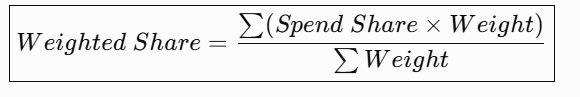

###We chose Nyarugenge simply as an example

In [ ]:
#Calculate district basket weights

# Step A — Confirm weight column exists in df_master
print("Columns in df_master:")
print(df_master.columns.tolist())
print(f"\nWeight column sample: {df_master['weight'].head(3).tolist()}")

# Step B — Keep only valid rows
# A valid row has a real cpi_code, real spending, and a real weight
df_valid = df_master[
    df_master['cpi_code'].notna() &
    df_master['total_spend_rwf'].notna() &
    df_master['weight'].notna() &
    (df_master['total_spend_rwf'] > 0)
].copy()

print(f"\nValid rows for calculation: {len(df_valid):,}")
print(f"Unique districts          : {df_valid['district'].nunique()}")
print(f"Unique cpi_codes          : {df_valid['cpi_code'].nunique()}")

# Step C — Show the exact formula being applied
print("\nFormula being applied:")
print("  weighted_share = Sum(spend_share_pct × weight) / Sum(weight)")
print("  For each: district + urban/rural + cpi_category combination")

# Step D — Calculate weighted average basket share
# observed=True silences the FutureWarning
df_district_weights = df_valid.groupby(
    ['district', 'ur', 'cpi_code', 'cpi_category'],
    observed=True
).apply(
    lambda x: pd.Series({
        'weighted_share_pct': round(
            (x['spend_share_pct'] * x['weight']).sum() /
             x['weight'].sum(), 2),
        'avg_spend_rwf'      : round(x['total_spend_rwf'].mean(), 0),
        'household_count'    : int(x['hhid'].nunique()),
    }),
    include_groups=False
).reset_index()

print(f"\nDistrict weights calculated")
print(f"  Rows     : {len(df_district_weights):,}")
print(f"  Districts: {df_district_weights['district'].nunique()}")

# Step E — Check for NaN values
nan_count = df_district_weights['weighted_share_pct'].isna().sum()
print(f"  NaN values remaining: {nan_count}")

# Step F — Preview Nyarugenge Urban — clean view
print("\nBasket weights for Nyarugenge Urban:")
print("-" * 65)
nyarugenge = df_district_weights[
    (df_district_weights['district'] == 'Nyarugenge') &
    (df_district_weights['ur'] == 'Urban')
].sort_values('cpi_code')

for _, row in nyarugenge.iterrows():
    print(f"  {row['cpi_code']}  "
          f"{row['cpi_category']:<35} "
          f"{row['weighted_share_pct']:>6.1f}%  "
          f"households: {row['household_count']}")

# Step G — Food share comparison across all districts
print("\nFood spending share by district:")
print("-" * 50)
food_by_district = df_district_weights[
    df_district_weights['cpi_code'] == '01'
][['district', 'ur', 'weighted_share_pct']].sort_values(
    'weighted_share_pct', ascending=False)
print(food_by_district.to_string(index=False))

# Step H — Save
df_district_weights.to_csv(
    checkpoint_path + 'district_basket_weights.csv', index=False)
print(f"\nDistrict basket weights saved")

Columns in df_master:
['hhid', 'cpi_code', 'cpi_category', 'total_spend_rwf', 'province', 'district', 'ur', 'quintile', 'weight', 'poverty', 'total_hh_spend', 'spend_share_pct']

Weight column sample: [170.95819504509035, 170.95819504509035, 170.95819504509035]

Valid rows for calculation: 55,354
Unique districts          : 30
Unique cpi_codes          : 12

Formula being applied:
  weighted_share = Sum(spend_share_pct × weight) / Sum(weight)
  For each: district + urban/rural + cpi_category combination

District weights calculated
  Rows     : 657
  Districts: 30
  NaN values remaining: 0

Basket weights for Nyarugenge Urban:
-----------------------------------------------------------------
  01  Food and non-alcoholic beverages      63.3%  households: 511.0
  02  Alcoholic beverages and tobacco        8.9%  households: 5.0
  03  Clothing and footwear                 37.8%  households: 199.0
  04  Housing and utilities                  9.5%  households: 78.0
  05  Furnishing and house

The percentages add up to more than 100% — Food 63.3% + Clothing 37.8% + Furnishing 33.3% + Health 22.4% + Restaurants 44.8% = well over 100%. This is because spend_share_pct was calculated per household as each category's share of that household's total spending.

In [ ]:
# STAGE 54 basket weights

# Calculate shares from total district spending
# So all categories sum to exactly 100% per district

# Step A — Calculate total spending per district per area
# This is the denominator — total money spent in that district group
df_district_total = df_valid.groupby(
    ['district', 'ur'],
    observed=True
).apply(
    lambda x: pd.Series({
        'total_district_spend': (x['total_spend_rwf'] * x['weight']).sum(),
        'total_households'    : int(x['hhid'].nunique()),
    }),
    include_groups=False
).reset_index()

print("Total spending per district (sample):")
print(df_district_total.head(6).to_string(index=False))

# Step B — Calculate total spending per district per category
df_cat_total = df_valid.groupby(
    ['district', 'ur', 'cpi_code', 'cpi_category'],
    observed=True
).apply(
    lambda x: pd.Series({
        'category_district_spend': (x['total_spend_rwf'] * x['weight']).sum(),
        'household_count'        : int(x['hhid'].nunique()),
        'avg_spend_rwf'          : round(x['total_spend_rwf'].mean(), 0),
    }),
    include_groups=False
).reset_index()

# Step C — Merge and calculate share
df_district_weights = df_cat_total.merge(
    df_district_total[['district', 'ur', 'total_district_spend']],
    on=['district', 'ur'],
    how='left'
)

df_district_weights['basket_share_pct'] = (
    df_district_weights['category_district_spend'] /
    df_district_weights['total_district_spend'] * 100
).round(2)

# Step D — Verify shares sum to 100% per district
print("\nVerifying shares sum to 100% per district (sample):")
check = df_district_weights.groupby(
    ['district', 'ur'], observed=True
)['basket_share_pct'].sum().reset_index()
print(check.head(10).to_string(index=False))

# Step E — Preview Nyarugenge Urban — should now sum to 100%
print("\nCorrected basket weights for Nyarugenge Urban:")
print("-" * 65)
nyarugenge = df_district_weights[
    (df_district_weights['district'] == 'Nyarugenge') &
    (df_district_weights['ur'] == 'Urban')
].sort_values('cpi_code')

total = 0
for _, row in nyarugenge.iterrows():
    print(f"  {row['cpi_code']}  "
          f"{row['cpi_category']:<35} "
          f"{row['basket_share_pct']:>6.1f}%  "
          f"households: {row['household_count']}")
    total += row['basket_share_pct']
print(f"\n  Total: {total:.1f}%  ← should be 100%")

# Step F — Food share comparison
print("\nFood share by district:")
print("-" * 50)
food = df_district_weights[
    df_district_weights['cpi_code'] == '01'
][['district', 'ur', 'basket_share_pct']].sort_values(
    'basket_share_pct', ascending=False)
print(food.to_string(index=False))

# Step G — Save corrected weights
df_district_weights.to_csv(
    checkpoint_path + 'district_basket_weights.csv', index=False)
print(f"\nCorrected district basket weights saved")

Total spending per district (sample):
  district    ur  total_district_spend  total_households
Nyarugenge Urban          6.802587e+09             536.0
Nyarugenge Rural          5.728295e+08              99.0
    Gasabo Urban          1.545714e+10             513.0
    Gasabo Rural          1.730664e+09             126.0
  Kicukiro Urban          1.900098e+10             618.0
  Kicukiro Rural          3.411628e+07              18.0

Verifying shares sum to 100% per district (sample):
  district    ur  basket_share_pct
Nyarugenge Urban             99.99
Nyarugenge Rural             99.99
    Gasabo Urban            100.00
    Gasabo Rural            100.01
  Kicukiro Urban             99.99
  Kicukiro Rural            100.01
    Nyanza Urban            100.00
    Nyanza Rural             99.99
  Gisagara Urban            100.00
  Gisagara Rural            100.00

Corrected basket weights for Nyarugenge Urban:
-----------------------------------------------------------------
  01  Food 

results tell us

For instance,
###Nyarugenge Urban basket:

Food	35.6%	Biggest spend means that urban households still spend a lot on food.

Clothing	24.5%, Nyarugenge is a commercial hub
Health	14.9%	High health spending, urban access to health services

Furnishing	10.3%	Home improvement spending
Miscellaneous	10.2%	Personal care, hygiene

etc.

####Food share by district tells:

Example: Huye Urban 11.21%	Low food share due to university town, more services spending.

Nyarugenge Rural 47.37% highest	Rural poor spending almost half on food

Most rural districts 20–35%	Reasonable — farmers supplement with own production


##STAGE 55 — Build the District Cost-of-Living Pressure Index
### This combines EICV7 district basket weights with
### live CPI inflation rates to estimate how hard
### inflation is hitting each district right now

In [ ]:

# Step A — Load the latest CPI month data
df_cpi_latest = pd.read_csv(
    '/content/drive/MyDrive/Hackathon_data/processed/cpi_latest_month.csv'
)

print("Latest CPI data loaded:")
print(df_cpi_latest[['COICOP', 'Category_Name',
                       'YoY_pct', 'Weight_pct']].to_string(index=False))

# Step B — Keep only main categories (2 digit COICOP codes)
# and remove the total index row (code 00)
df_cpi_main = df_cpi_latest[
    (df_cpi_latest['COICOP'].str.len() == 2) &
    (df_cpi_latest['COICOP'] != '00')
].copy()

print(f"\nMain CPI categories: {len(df_cpi_main)}")

# Step C — Map COICOP codes to match our district weights
# Our district weights use 2-digit codes like 01, 02, 03
# CPI uses codes like 01, 02, 03 — they should match
print("\nCOICOP codes in CPI data:")
print(df_cpi_main['COICOP'].tolist())

print("\nCOICOP codes in district weights:")
print(sorted(df_district_weights['cpi_code'].unique().tolist()))

Latest CPI data loaded:
COICOP                                                     Category_Name   YoY_pct  Weight_pct
    00                                               GENERAL INDEX (CPI) 15.861720  100.000000
    01                                  Food and non-alcoholic beverages 16.657837   39.035428
01.1.1                                           v     Bread and cereals  4.143441    6.622592
01.1.2                                                        v     Meat 32.516111    1.737716
01.1.4                                       v     Milk, cheese and eggs  5.102424    1.129753
01.1.7                                                  v     Vegetables 22.583202   18.428570
  01.2                                     v     Non-alcoholic beverages  8.816817    1.146293
    02                                   Alcoholic beverages and tobacco  8.205808    6.808440
    03                                             Clothing and footwear  5.007693    5.309945
    04                  Ho

##Formula:
**Pressure Index for district D = Sum of (basket_share_pct × YoY_inflation)**

for all 12 categories

#### This gives a weighted inflation rate that reflects what households in that specific district actually spend on, not the national average basket

In [ ]:
# Step A — Prepare CPI data — keep only the 12 main categories
df_cpi_for_index = df_cpi_main[['COICOP', 'Category_Name',
                                  'YoY_pct']].copy()
df_cpi_for_index.columns = ['cpi_code', 'category_name', 'yoy_inflation']

print("CPI inflation rates for index:")
print(df_cpi_for_index.to_string(index=False))

# Step B — Join district basket weights with CPI inflation rates
df_index_input = df_district_weights.merge(
    df_cpi_for_index[['cpi_code', 'yoy_inflation']],
    on='cpi_code',
    how='left'
)

print(f"\nRows after joining: {len(df_index_input):,}")
print(f"NaN inflation values: {df_index_input['yoy_inflation'].isna().sum()}")

# Step C — Calculate weighted inflation contribution per category
# Each category contributes: its share × its inflation rate
df_index_input['inflation_contribution'] = (
    df_index_input['basket_share_pct'] / 100 *
    df_index_input['yoy_inflation']
).round(4)

# Step D — Sum contributions per district to get pressure index
df_pressure_index = df_index_input.groupby(
    ['district', 'ur'],
    observed=True
).agg(
    pressure_index   = ('inflation_contribution', 'sum'),
    household_count  = ('household_count', 'sum'),
).reset_index()

df_pressure_index['pressure_index'] = df_pressure_index[
    'pressure_index'].round(2)

# Step E — Add risk label
def assign_risk(score):
    if score >= 14:
        return 'High'
    elif score >= 10:
        return 'Medium'
    else:
        return 'Lower'

df_pressure_index['risk_level'] = df_pressure_index[
    'pressure_index'].apply(assign_risk)

# Step F — Show full results sorted by pressure
print("\nDistrict Cost-of-Living Pressure Index — August 2026:")

print(f"{'District':<20} {'Area':<8} {'Index':>7} "
      f"{'Risk':<8} {'Households':>10}")

df_sorted = df_pressure_index.sort_values(
    'pressure_index', ascending=False)

for _, row in df_sorted.iterrows():
    risk_label = row['risk_level']
    print(f"  {row['district']:<18} {row['ur']:<8} "
          f"{row['pressure_index']:>6.1f}%  "
          f"{risk_label:<8} {row['household_count']:>10,.0f}")

print("-" * 65)
print(f"  National average: 15.9% (NISR headline figure)")

# Step G — Save
df_pressure_index.to_csv(
    checkpoint_path + 'district_pressure_index.csv', index=False)
print(f"\nDistrict pressure index saved")

CPI inflation rates for index:
cpi_code                                                     category_name  yoy_inflation
      01                                  Food and non-alcoholic beverages      16.657837
      02                                   Alcoholic beverages and tobacco       8.205808
      03                                             Clothing and footwear       5.007693
      04                  Housing, water, electricity, gas and other fuels      19.888953
      05 Furnishing, household equipment and routine household maintenance      10.171292
      06                                                            Health       2.662232
      07                                                         Transport      27.542340
      08                                                     Communication      27.618576
      09                                            Recreation and culture      11.615613
      10                                                         Educ

####Results tell us

The national average is 15.9% but districts experience very different realities:

######Example: Nyaruguru Urban at 21.1% — highest	Urban households here face the worst inflation pressure.
Nyarugenge Urban at only 10.6%	Kigali's commercial center is less affected — wealthier households spend less on food and more on services

Rural districts generally higher than urban	Rural households spend more of their budget on food which is rising fast.

In [ ]:
# STAGE 57 — Save pipeline completion summary
# This documents exactly what was built

from datetime import datetime

summary = f"""
RWANDA COST-OF-LIVING INTELLIGENCE PLATFORM
Data Pipeline Completion Summary
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}

DATASET 1 — NISR CPI

Source      : CPI_time_series_August 2026.xls
Sheet used  : All Rwanda
Date range  : February 2009 to August 2026
Categories  : 12 main COICOP categories + 6 sub-items
Latest month: August 2026

Key findings (August 2026):
  General inflation (YoY)  : 15.9%
  Highest category         : Transport +27.5%
  Second highest           : Communication +27.6%
  Biggest basket category  : Food (39%) at +16.7%
  Most stable              : Health +2.7%


DATASET 2 — NISR EICV7 (2023-2024)

Source      : CS_S01_S5_S7_Household.dta (and S8A1, S8A2, S8A3, S8B)
Households  : 15,054 surveyed
Districts   : All 30 districts of Rwanda
Files used  : 5 EICV7 files

Poverty breakdown:
  Non Poor        : 11,476 households (76.2%)
  Moderately Poor :  2,951 households (19.6%)
  Severely Poor   :    627 households  (4.2%)

Urban/Rural split:
  Rural : 11,060 households (73.4%)
  Urban :  3,994 households (26.6%)


DISTRICT PRESSURE INDEX — KEY RESULTS

Highest pressure: Nyaruguru Urban    21.1% (High risk)
Lowest pressure : Nyamasheke Urban   10.0% (Medium risk)
National average: 15.9%
Districts at High risk   : 14
Districts at Medium risk : 46
Districts at Lower risk  :  0


FILES SAVED

processed/cpi_clean_long.csv          Full CPI history
processed/cpi_latest_month.csv        August 2026 CPI
processed/basket_weights.csv          National basket weights
checkpoints/households.csv            EICV7 households
checkpoints/spending_nonfood_combined.csv  Non-food spending
checkpoints/spending_food.csv         Food spending
checkpoints/master_spending.csv       Combined spending
checkpoints/district_basket_weights.csv   District weights
checkpoints/district_pressure_index.csv   Pressure index

"""
# Save summary
with open(checkpoint_path + 'pipeline_summary.txt', 'w') as f:
    f.write(summary)

print(summary)
print("Pipeline summary saved")


RWANDA COST-OF-LIVING INTELLIGENCE PLATFORM
Data Pipeline Completion Summary
Generated: 2026-09-25 15:21

DATASET 1 — NISR CPI

Source      : CPI_time_series_August 2026.xls
Sheet used  : All Rwanda
Date range  : February 2009 to August 2026
Categories  : 12 main COICOP categories + 6 sub-items
Latest month: August 2026

Key findings (August 2026):
  General inflation (YoY)  : 15.9%
  Highest category         : Transport +27.5%
  Second highest           : Communication +27.6%
  Biggest basket category  : Food (39%) at +16.7%
  Most stable              : Health +2.7%


DATASET 2 — NISR EICV7 (2023-2024)

Source      : CS_S01_S5_S7_Household.dta (and S8A1, S8A2, S8A3, S8B)
Households  : 15,054 surveyed
Districts   : All 30 districts of Rwanda
Files used  : 5 EICV7 files

Poverty breakdown:
  Non Poor        : 11,476 households (76.2%)
  Moderately Poor :  2,951 households (19.6%)
  Severely Poor   :    627 households  (4.2%)

Urban/Rural split:
  Rural : 11,060 households (73.4%)
  Urb

We have 30 districts × 2 area types (Urban + Rural) = 60 district-area combinations total.

From our output:

High risk (≥14%) — 14 combinations

Medium risk (10–14%) — 46 combinations

Lower risk (<10%) — 0 combinations

In [ ]:
# STAGE 57B — Verify risk level counts from actual data

print("Risk level summary — from actual data:")
print("-" * 45)
risk_counts = df_pressure_index['risk_level'].value_counts()
print(risk_counts)

print(f"\nTotal district-area combinations : {len(df_pressure_index)}")
print(f"Unique districts                 : {df_pressure_index['district'].nunique()}")

print("\nBreakdown by risk level:")
for risk in ['High', 'Medium', 'Lower']:
    subset = df_pressure_index[df_pressure_index['risk_level'] == risk]
    print(f"\n  {risk} risk ({len(subset)} combinations):")
    for _, row in subset.sort_values(
        'pressure_index', ascending=False).iterrows():
        print(f"    {row['district']:<20} {row['ur']:<8} "
              f"{row['pressure_index']:.1f}%")

Risk level summary — from actual data:
---------------------------------------------
risk_level
Medium    46
High      14
Name: count, dtype: int64

Total district-area combinations : 60
Unique districts                 : 30

Breakdown by risk level:

  High risk (14 combinations):
    Nyaruguru            Urban    21.1%
    Rulindo              Urban    18.0%
    Huye                 Urban    16.9%
    Ruhango              Rural    16.5%
    Ngoma                Rural    15.4%
    Muhanga              Urban    14.9%
    Rwamagana            Rural    14.9%
    Ngororero            Urban    14.7%
    Musanze              Urban    14.6%
    Nyamagabe            Rural    14.5%
    Nyabihu              Rural    14.4%
    Huye                 Rural    14.3%
    Nyabihu              Urban    14.2%
    Kicukiro             Urban    14.2%

  Medium risk (46 combinations):
    Nyagatare            Rural    13.8%
    Gasabo               Urban    13.8%
    Kamonyi              Rural    13.8%
   

###PHASE 4 — CORE CALCULATIONS


### STAGE 58 — Personal Inflation Calculator
###Formula:
#**Personal Inflation Rate**= Sum of (user_spend_share × category_YoY_inflation)for all 12 categories

In [ ]:
# Step A — Define a sample household to test the formula
# These are the monthly spending amounts a user would enter in the personal tool
sample_user = {
    'monthly_income'  : 150000,
    'food'            : 55000,   # category 01
    'alcohol_tobacco' : 0,       # category 02
    'clothing'        : 10000,   # category 03
    'housing'         : 40000,   # category 04
    'furnishing'      : 5000,    # category 05
    'health'          : 10000,   # category 06
    'transport'       : 20000,   # category 07
    'communication'   : 3000,    # category 08
    'recreation'      : 2000,    # category 09
    'education'       : 8000,    # category 10
    'restaurants'     : 0,       # category 11
    'miscellaneous'   : 5000,    # category 12
}

# Step B — Map user inputs to CPI codes
category_map = {
    'food'            : '01',
    'alcohol_tobacco' : '02',
    'clothing'        : '03',
    'housing'         : '04',
    'furnishing'      : '05',
    'health'          : '06',
    'transport'       : '07',
    'communication'   : '08',
    'recreation'      : '09',
    'education'       : '10',
    'restaurants'     : '11',
    'miscellaneous'   : '12',
}

# Step C — Calculate total spending and each category share
total_spend = sum(
    v for k, v in sample_user.items() if k != 'monthly_income'
)

print("Sample household spending breakdown:")
print(f"  Monthly income : RWF {sample_user['monthly_income']:>10,.0f}")
print(f"  Total spending : RWF {total_spend:>10,.0f}")
print(f"  Savings/other  : RWF {sample_user['monthly_income'] - total_spend:>10,.0f}")
print()

# Build a dataframe of user spending shares
user_shares = []
for category, cpi_code in category_map.items():
    amount = sample_user[category]
    share  = (amount / total_spend * 100) if total_spend > 0 else 0
    user_shares.append({
        'cpi_code'    : cpi_code,
        'category'    : category,
        'amount_rwf'  : amount,
        'share_pct'   : round(share, 2),
    })

df_user = pd.DataFrame(user_shares)
print(f"{'Category':<20} {'Amount (RWF)':>12}  {'Share':>7}")
print("-" * 45)
for _, row in df_user.iterrows():
    if row['amount_rwf'] > 0:
        print(f"  {row['category']:<18} "
              f"RWF {row['amount_rwf']:>8,.0f}  "
              f"{row['share_pct']:>6.1f}%")
print(f"  {'TOTAL':<18} RWF {total_spend:>8,.0f}  100.0%")

# Step D — Join with CPI inflation rates
df_user = df_user.merge(
    df_cpi_for_index[['cpi_code', 'yoy_inflation']],
    on='cpi_code',
    how='left'
)

# Step E — Calculate personal inflation rate
df_user['inflation_contribution'] = (
    df_user['share_pct'] / 100 *
    df_user['yoy_inflation']
).round(4)

personal_inflation = df_user['inflation_contribution'].sum().round(2)
national_inflation = 15.86  # from our CPI data

# Step F — Show results

print(f"  YOUR PERSONAL INFLATION RATE: {personal_inflation:.1f}%")
print(f"  National average            : {national_inflation:.1f}%")
print(f"  Difference                  : "
      f"{personal_inflation - national_inflation:+.1f}%")
print(f"{'='*50}")

# Step G — Show category contributions ranked
print("\nWhat is driving your inflation:")
print("-" * 50)
df_user_sorted = df_user[df_user['amount_rwf'] > 0].sort_values(
    'inflation_contribution', ascending=False)

for _, row in df_user_sorted.iterrows():
    bar_length = int(row['inflation_contribution'] / personal_inflation * 20)
    bar = '' * bar_length
    print(f"  {row['category']:<18} "
          f"{row['yoy_inflation']:>6.1f}% inflation  "
          f"× {row['share_pct']:>5.1f}% of budget  "
          f"= {row['inflation_contribution']:>5.2f}%  {bar}")

# Step H — Identify biggest pressure category
top_category = df_user_sorted.iloc[0]
print(f"\n  Biggest pressure: {top_category['category'].upper()}")
print(f"  It takes {top_category['share_pct']:.1f}% of your budget")
print(f"  and rose {top_category['yoy_inflation']:.1f}% this year")
print(f"  That costs you an extra RWF "
      f"{top_category['amount_rwf'] * top_category['yoy_inflation'] / 100:,.0f} "
      f"per month compared to last year")

Sample household spending breakdown:
  Monthly income : RWF    150,000
  Total spending : RWF    158,000
  Savings/other  : RWF     -8,000

Category             Amount (RWF)    Share
---------------------------------------------
  food               RWF   55,000    34.8%
  clothing           RWF   10,000     6.3%
  housing            RWF   40,000    25.3%
  furnishing         RWF    5,000     3.2%
  health             RWF   10,000     6.3%
  transport          RWF   20,000    12.7%
  communication      RWF    3,000     1.9%
  recreation         RWF    2,000     1.3%
  education          RWF    8,000     5.1%
  miscellaneous      RWF    5,000     3.2%
  TOTAL              RWF  158,000  100.0%
  YOUR PERSONAL INFLATION RATE: 16.7%
  National average            : 15.9%
  Difference                  : +0.9%

What is driving your inflation:
--------------------------------------------------
  food                 16.7% inflation  ×  34.8% of budget  =  5.80%  
  housing              19.9% i

The output means:

This sample household earns RWF 150,000 but spends RWF 158,000 already spending more than they earn, which is common in Rwanda where households use savings or informal credit to cover gaps.

Their personal inflation rate is 16.7% slightly above the national average of 15.9%

In [ ]:
# STAGE 59 — Profile Comparison
# Compare the user's inflation against typical profiles
# derived from our EICV7 data

# Step A — Build typical spending profiles from EICV7
# Using our master spending data grouped by profile type

# Profile 1 — Student (Q1-Q2 income, Urban)
# Profile 2 — Family household (Q2-Q3, any area)
# Profile 3 — Urban household (Urban, any quintile)
# Profile 4 — Rural household (Rural, any quintile)

profiles = {
    'Student'          : {'quintile': ['Q1', 'Q2'], 'ur': 'Urban'},
    'Family household' : {'quintile': ['Q2', 'Q3'], 'ur': None},
    'Urban household'  : {'quintile': None,          'ur': 'Urban'},
    'Rural household'  : {'quintile': None,          'ur': 'Rural'},
}

print("Building typical spending profiles from EICV7 data...")
print("=" * 65)

profile_results = {}

for profile_name, filters in profiles.items():

    # Filter households matching this profile
    mask = pd.Series([True] * len(df_master))

    if filters['quintile']:
        mask = mask & df_master['quintile'].isin(filters['quintile'])
    if filters['ur']:
        mask = mask & (df_master['ur'] == filters['ur'])

    df_profile = df_master[mask].copy()

    # Calculate weighted basket shares for this profile
    profile_total = df_profile.groupby(
        'hhid', observed=True
    )['total_spend_rwf'].sum().reset_index()
    profile_total.columns = ['hhid', 'total_hh_spend_profile']

    df_profile = df_profile.merge(profile_total, on='hhid', how='left')
    df_profile['profile_share'] = (
        df_profile['total_spend_rwf'] /
        df_profile['total_hh_spend_profile'] * 100
    )

    # Weighted average share per category
    profile_basket = df_profile.groupby(
        'cpi_code', observed=True
    ).apply(
        lambda x: (x['profile_share'] * x['weight']).sum() /
                   x['weight'].sum(),
        include_groups=False
    ).reset_index()
    profile_basket.columns = ['cpi_code', 'basket_share']

    # Normalize to sum to 100
    total = profile_basket['basket_share'].sum()
    profile_basket['basket_share'] = (
        profile_basket['basket_share'] / total * 100
    ).round(2)

    # Calculate profile inflation rate
    profile_basket = profile_basket.merge(
        df_cpi_for_index[['cpi_code', 'yoy_inflation']],
        on='cpi_code', how='left'
    )
    profile_basket['contribution'] = (
        profile_basket['basket_share'] / 100 *
        profile_basket['yoy_inflation']
    )
    profile_inflation = profile_basket['contribution'].sum().round(2)

    profile_results[profile_name] = {
        'inflation_rate' : profile_inflation,
        'household_count': df_profile['hhid'].nunique(),
        'basket'         : profile_basket,
    }

    print(f"\nProfile: {profile_name}")
    print(f"  Households in profile : {df_profile['hhid'].nunique():,}")
    print(f"  Profile inflation rate: {profile_inflation:.1f}%")
    print(f"  Top 3 spending categories:")
    top3 = profile_basket.sort_values('basket_share', ascending=False).head(3)
    for _, row in top3.iterrows():
        print(f"    {row['cpi_code']} — {row['basket_share']:.1f}% of budget  "
              f"({row['yoy_inflation']:.1f}% inflation)")

# Step B — Compare user to all profiles

print("HOW YOUR INFLATION COMPARES TO TYPICAL PROFILES:")

print(f"\n  YOUR personal inflation rate : {personal_inflation:.1f}%")
print()
for profile_name, result in profile_results.items():
    diff = personal_inflation - result['inflation_rate']
    direction = 'above' if diff > 0 else 'below'
    print(f"  {profile_name:<25} {result['inflation_rate']:.1f}%  "
          f"(you are {abs(diff):.1f}% {direction})")

# Step C — Save profiles
import json
profile_summary = {
    name: {
        'inflation_rate' : data['inflation_rate'],
        'household_count': data['household_count'],
    }
    for name, data in profile_results.items()
}

with open(checkpoint_path + 'profile_benchmarks.json', 'w') as f:
    json.dump(profile_summary, f, indent=2)
print(f"\n Profile benchmarks saved")

Building typical spending profiles from EICV7 data...

Profile: Student
  Households in profile : 775
  Profile inflation rate: 11.5%
  Top 3 spending categories:
    01 — 25.5% of budget  (16.7% inflation)
    05 — 21.9% of budget  (10.2% inflation)
    03 — 18.8% of budget  (5.0% inflation)

Profile: Family household
  Households in profile : 5,939
  Profile inflation rate: 11.9%
  Top 3 spending categories:
    05 — 20.6% of budget  (10.2% inflation)
    01 — 18.6% of budget  (16.7% inflation)
    11 — 14.8% of budget  (13.7% inflation)

Profile: Urban household
  Households in profile : 3,957
  Profile inflation rate: 13.1%
  Top 3 spending categories:
    01 — 21.5% of budget  (16.7% inflation)
    11 — 17.4% of budget  (13.7% inflation)
    03 — 14.2% of budget  (5.0% inflation)

Profile: Rural household
  Households in profile : 11,055
  Profile inflation rate: 12.1%
  Top 3 spending categories:
    05 — 19.3% of budget  (10.2% inflation)
    11 — 18.3% of budget  (13.7% inflati

In [ ]:
# STAGE 59B — Improve profile labels to reflect


# Rename profiles to match what we actually measured
honest_profiles = {
    'Low income urban'    : profile_results['Student'],
    'Middle income'       : profile_results['Family household'],
    'Urban household'     : profile_results['Urban household'],
    'Rural household'     : profile_results['Rural household'],
}

print("Corrected profile names and inflation rates:")

print(f"\n  YOUR personal inflation rate : {personal_inflation:.1f}%")
print(f"  National average             : {national_inflation:.1f}%")
print()
for profile_name, result in honest_profiles.items():
    diff   = personal_inflation - result['inflation_rate']
    direction = 'above' if diff > 0 else 'below'
    print(f"  {profile_name:<25} {result['inflation_rate']:.1f}%  "
          f"(you are {abs(diff):.1f}% {direction})")

print("""
Note for documentation:
  Profiles are derived from EICV7 household spending patterns.
  Low income urban  = Q1-Q2 income quintile, urban area
  Middle income     = Q2-Q3 income quintile, all areas
  Urban household   = all quintiles, urban area only
  Rural household   = all quintiles, rural area only
  Profile inflation rates reflect average spending baskets
  within each group — not individual household predictions.
""")

# Update the saved profile names
import json
honest_summary = {
    name: {
        'inflation_rate' : data['inflation_rate'],
        'household_count': data['household_count'],
        'note'           : 'derived from EICV7 spending patterns'
    }
    for name, data in honest_profiles.items()
}
with open(checkpoint_path + 'profile_benchmarks.json', 'w') as f:
    json.dump(honest_summary, f, indent=2)

print("Updated profile benchmarks saved")

Corrected profile names and inflation rates:

  YOUR personal inflation rate : 16.7%
  National average             : 15.9%

  Low income urban          11.5%  (you are 5.3% above)
  Middle income             11.9%  (you are 4.8% above)
  Urban household           13.1%  (you are 3.7% above)
  Rural household           12.1%  (you are 4.7% above)

Note for documentation:
  Profiles are derived from EICV7 household spending patterns.
  Low income urban  = Q1-Q2 income quintile, urban area
  Middle income     = Q2-Q3 income quintile, all areas
  Urban household   = all quintiles, urban area only
  Rural household   = all quintiles, rural area only
  Profile inflation rates reflect average spending baskets
  within each group — not individual household predictions.

Updated profile benchmarks saved


In [ ]:
# STAGE 60 — Budgeting Tips Engine
# Generates practical, Rwanda-specific tips based on the
# user's biggest inflation pressures
# Tips reference real local markets, services, and culture
# ============================================================

tips_library = {

    '01': {  # Food
        'tip': (
            "Buy staple foods like beans, maize, and sweet potatoes "
            "in bulk at the beginning of the month when prices are "
            "more stable. Early morning markets offer better prices "
            "than afternoon — try Kimironko, Nyabugogo, or your "
            "nearest sector market before 8am."
        ),
        'challenge': (
            "Track every food purchase for 7 days. Most households "
            "discover 15-20% of their food spending goes to unplanned "
            "items. Write down every purchase — even small ones like "
            "tomatoes and onions from a roadside vendor."
        ),
        'saving_tip': (
            "Cooking at home instead of buying prepared food 3 extra "
            "days per week saves up to RWF 6,000 per month at current "
            "prices. Growing vegetables like amaranthe, leeks, or "
            "tomatoes in a small kitchen garden — even in bags or "
            "containers on a balcony — can cut your vegetable bill "
            "by 30-50%."
        ),
        'local_tip': (
            "Vegetables are 22.6% more expensive than last year. "
            "Buying directly from farmers at sector markets rather "
            "than supermarkets saves 20-40% on the same produce."
        ),
    },

    '04': {  # Housing and utilities
        'tip': (
            "Switch to energy-saving LED bulbs — they use 80% less "
            "electricity than traditional bulbs. With housing and "
            "utility costs up 19.9%, small efficiency changes add "
            "up to real savings every month."
        ),
        'challenge': (
            "Review your electricity bill this month and identify "
            "the 2 highest-consumption appliances. Reducing their "
            "use by 30 minutes daily saves approximately "
            "RWF 2,000-3,000 per month."
        ),
        'saving_tip': (
            "Solar energy is now accessible for Rwandan households. "
            "RURA-approved solar home systems (companies like Ignite, "
            "Bboxx, and JALI) offer pay-as-you-go solar panels that "
            "power lights, phone charging, and small appliances for "
            "RWF 500-1,500 per week — often cheaper than the "
            "equivalent grid electricity cost. For cooking, biogas "
            "digesters in rural areas and improved biomass stoves "
            "reduce charcoal costs by up to 60%."
        ),
        'local_tip': (
            "Charcoal prices are rising fast as wood becomes scarcer. "
            "The Rwanda Environment Management Authority (REMA) "
            "promotes briquettes made from agricultural waste as a "
            "cheaper, cleaner alternative available in most markets."
        ),
    },

    '07': {  # Transport
        'tip': (
            "Group errands into 2 days instead of daily trips. "
            "With transport costs up 27.5%, combining 4 trips "
            "into 2 saves approximately RWF 2,000-4,000 per month "
            "depending on your routes."
        ),
        'challenge': (
            "For one week, record every transport expense including "
            "small moto fares. Most people underestimate daily "
            "transport costs by 30-40% because small fares feel "
            "insignificant in the moment."
        ),
        'saving_tip': (
            "Ecofleet buses (formerly Kigali Bus Services) and "
            "ROYAL Express buses on main routes cost significantly "
            "less than moto taxis for the same distance — "
            "RWF 250-500 per trip versus RWF 500-2,000 by moto. "
            "For regular commuters, the monthly Tap&Go card on "
            "bus routes reduces per-trip cost further. "
            "In rural areas, coordinating shared transport with "
            "neighbours for market days cuts individual costs in half."
        ),
        'local_tip': (
            "Walking routes under 2km instead of taking a moto "
            "saves RWF 1,000-2,000 per day for urban households "
            "who make multiple short trips. That is RWF 20,000-40,000 "
            "per month redirected to food or savings."
        ),
    },

    '06': {  # Health
        'tip': (
            "Renew your Mutuelle de Santé insurance before it expires. "
            "With health costs up 2.7% this year, a single uninsured "
            "hospital visit costs more than the annual Mutuelle "
            "premium for most households."
        ),
        'challenge': (
            "Check whether all household members are currently covered "
            "by Mutuelle. Gaps in coverage are the biggest cause of "
            "sudden health-related financial shocks in Rwanda."
        ),
        'saving_tip': (
            "Many health centres offer lower fees for early morning "
            "appointments. Routine check-ups booked in advance cost "
            "significantly less than emergency visits. Preventive "
            "care — handwashing, clean water, mosquito nets — "
            "remains the cheapest health investment available."
        ),
        'local_tip': (
            "Community health workers (Inararibonye) provide free "
            "basic health consultations and referrals at village "
            "level. They are the first point of contact for "
            "non-emergency health concerns and save households "
            "unnecessary clinic visit costs."
        ),
    },

    '03': {  # Clothing
        'tip': (
            "Clothing inflation is relatively low at 5.0% — one of "
            "the more stable categories this year. If you need to "
            "make clothing purchases, now is a better time than "
            "waiting for prices to rise further."
        ),
        'challenge': (
            "Separate needs from wants in your clothing spending "
            "this month. School uniforms and work clothing are "
            "needs — fashion purchases can wait for sales or "
            "end-of-season discounts."
        ),
        'saving_tip': (
            "Second-hand markets offer quality clothing at 60-80% "
            "below new prices. Key markets include: Kimisagara "
            "(Kigali), Kimironko (Kigali), Nyabugogo (Kigali), "
            "Huye main market (Southern), Musanze market (Northern), "
            "Rubavu/Gisenyi market (Western), and Nyagatare market "
            "(Eastern). These markets receive regular stock and "
            "often carry imported branded items at very low prices."
        ),
        'local_tip': (
            "Local tailors (abashonyi) can remake, repair, or "
            "resize clothing at a fraction of buying new. A "
            "skilled tailor charges RWF 1,000-5,000 to transform "
            "an old item into something new — far less than "
            "RWF 10,000-30,000 for a replacement."
        ),
    },

    '05': {  # Furnishing
        'tip': (
            "Furnishing and household costs are up 10.2%. Delay "
            "non-essential home purchases until your food and "
            "transport pressures stabilize. Repair before "
            "replacing where possible."
        ),
        'challenge': (
            "List every household item you plan to buy this month "
            "and mark each as urgent or deferrable. Most households "
            "can safely defer 50-60% of planned furnishing "
            "purchases by one month without any real impact."
        ),
        'saving_tip': (
            "Local carpenters (abadozi) and repair technicians "
            "are significantly cheaper than buying new furniture. "
            "A chair repair costs RWF 2,000-5,000 versus "
            "RWF 15,000-30,000 for a replacement. "
            "For cleaning products, local brands like Inyange "
            "and sector cooperative products cost 40-60% less "
            "than imported equivalents with equivalent quality."
        ),
        'local_tip': (
            "Household items like pots, dishes, and baskets are "
            "available at cooperative craft markets across all "
            "provinces at prices 30-50% below supermarket prices. "
            "Ask at your sector office for the nearest cooperative "
            "market location."
        ),
    },

    '08': {  # Communication
        'tip': (
            "Communication costs jumped 27.6% this year — the "
            "highest rise alongside transport. Review your data "
            "and airtime bundles immediately. Weekly bundles "
            "typically cost 20-30% less than buying daily data."
        ),
        'challenge': (
            "Switch to WhatsApp calls and video calls over "
            "regular phone calls for all contacts who have "
            "smartphones. A household saving 50 minutes of "
            "regular call time per day saves approximately "
            "RWF 1,500 per month."
        ),
        'saving_tip': (
            "MTN and Airtel both offer monthly bundles that "
            "cost significantly less per MB than daily or "
            "weekly options. Calculate your average monthly "
            "data usage and switch to the matching monthly plan. "
            "Connecting to WiFi at work, school, or sector "
            "offices for heavy downloads saves mobile data "
            "for essential communication only."
        ),
        'local_tip': (
            "Rwanda has one of Africa's fastest growing "
            "public WiFi networks. Sector offices, libraries, "
            "and many public spaces in towns offer free WiFi. "
            "Using these for video calls and data-heavy tasks "
            "can reduce your monthly mobile data costs by 30-50%."
        ),
    },

    '10': {  # Education
        'tip': (
            "Education costs are up 11.8%. Plan school fee "
            "payments early — many schools offer a small "
            "discount for full-term payment at the start of "
            "term compared to monthly instalments."
        ),
        'challenge': (
            "Review stationery and school supply purchases. "
            "Buying supplies in bulk at the start of the school "
            "year costs 15-25% less than buying item by item "
            "throughout the term."
        ),
        'saving_tip': (
            "Public libraries in Kigali (Kigali Public Library, "
            "Carnegie Library) and district reading centres "
            "offer free access to textbooks and study materials. "
            "The Rwanda Education Board (REB) also provides free "
            "digital textbooks at e-learning.rw for all "
            "primary and secondary levels."
        ),
        'local_tip': (
            "Umudugudu-level study groups (amasomo y'inzego) "
            "where students share materials and help each other "
            "reduce individual stationery and tutoring costs "
            "significantly. Coordinate with your child's teacher "
            "to organize one in your neighborhood."
        ),
    },

    '09': {  # Recreation
        'tip': (
            "Recreation costs are up 11.6%. There are many "
            "free or very low-cost ways to maintain quality "
            "of life for your family without the expense."
        ),
        'challenge': (
            "This month, replace one paid recreational activity "
            "with a free alternative and calculate the saving. "
            "Most families find they enjoy free activities "
            "as much as paid ones."
        ),
        'saving_tip': (
            "Free and low-cost recreation options across Rwanda: "
            "playing with your children at home (traditional games "
            "like igisoro, umupira, jumping rope); family running "
            "or morning walks together; singing and dancing at home; "
            "participating in Umuganda (last Saturday of each month) "
            "builds community and is free; local football matches "
            "and community sports days; public parks in Kigali "
            "(Nyarutarama lake, Remera park); Rwanda Broadcasting "
            "Agency (RBA) free TV and radio programs; "
            "church and community choir activities."
        ),
        'local_tip': (
            "Umuganda — Rwanda's monthly community work day — "
            "is not just a civic duty but a social occasion. "
            "Participating builds neighborhood relationships "
            "that create informal support networks, which "
            "have real financial value during difficult times."
        ),
    },

    '11': {  # Restaurants and hotels
        'tip': (
            "Restaurant and prepared food costs are up 13.7%. "
            "Reducing eating outside by just 2 meals per week "
            "saves the average urban household RWF 8,000-15,000 "
            "per month at current prices."
        ),
        'challenge': (
            "Cook one extra meal at home per day for two weeks "
            "and record the savings. Most households are "
            "surprised by how much prepared food adds up "
            "across a month."
        ),
        'saving_tip': (
            "Packed lunches for work or school cost 60-70% less "
            "than buying food outside. Even 3 days per week of "
            "packed lunches saves RWF 6,000-10,000 per month. "
            "Cooking in larger batches on weekends and storing "
            "portions reduces both cooking time and cost "
            "during busy weekdays."
        ),
        'local_tip': (
            "Community canteens and cooperative restaurants "
            "at sector level often offer meals at RWF 500-800 "
            "— significantly less than commercial restaurants "
            "charging RWF 1,500-3,000 for similar food. "
            "Ask at your sector office for nearby options."
        ),
    },

    '02': {  # Alcohol and tobacco
        'tip': (
            "Alcohol and tobacco costs are up 8.2%. Reducing "
            "consumption frees budget for food and transport "
            "which are rising much faster and are harder to avoid."
        ),
        'challenge': (
            "Track alcohol and tobacco spending for one week. "
            "Many households spend significantly more than they "
            "realize on these items across small daily purchases."
        ),
        'saving_tip': (
            "Consider Tunyweless — Rwanda's national alcohol "
            "reduction campaign — which provides community "
            "support for reducing alcohol consumption. "
            "Sober Ghee and Sober Chou are locally available "
            "non-alcoholic alternatives for social occasions. "
            "Redirecting RWF 5,000 per month from alcohol and "
            "tobacco to a savings group (tontine/ikimina) builds "
            "a financial buffer against future shocks — "
            "after 12 months that is RWF 60,000 saved."
        ),
        'local_tip': (
            "Community savings groups (ibimina) at village level "
            "accept contributions as small as RWF 500 per week. "
            "Money redirected from alcohol and tobacco to an "
            "ibimina creates both savings and community support "
            "networks that are more valuable during economic stress."
        ),
    },

    '12': {  # Miscellaneous
        'tip': (
            "Miscellaneous personal care costs are up 10.7%. "
            "Local and generic brands offer equivalent quality "
            "at 40-60% of imported branded product prices. "
            "Check Inyange, Sulfo Rwanda, and cooperative "
            "brand products at your nearest market."
        ),
        'challenge': (
            "This month, replace one imported personal care "
            "product with a locally produced alternative "
            "and compare quality. Rwanda's local manufacturers "
            "have significantly improved product quality "
            "in recent years."
        ),
        'saving_tip': (
            "Buying personal care products in larger quantities "
            "where storage allows reduces cost per use by 20-30% "
            "compared to buying small quantities frequently. "
            "Cooperative buying groups with neighbors for "
            "bulk household products can reduce costs for "
            "everyone involved."
        ),
        'local_tip': (
            "Sulfo Rwanda produces soap, detergents, and personal "
            "care products at prices 40-60% below imported brands "
            "with comparable quality. Available at all major "
            "markets and many small shops across Rwanda."
        ),
    },
}

# Generate personalized tips for the sample user
print("PERSONALIZED BUDGETING ADVICE FOR YOUR HOUSEHOLD")
print("=" * 62)
print(f"Your personal inflation rate : {personal_inflation:.1f}%")
print(f"National average             : {national_inflation:.1f}%")
print()

top_pressures = df_user_sorted.head(3)

for rank, (_, row) in enumerate(top_pressures.iterrows(), 1):
    code = row['cpi_code']
    if code not in tips_library:
        continue
    tip_data = tips_library[code]
    print(f"{'`'*62}")
    print(f"  #{rank} — {row['category'].upper()}")
    print(f"       Inflation: +{row['yoy_inflation']:.1f}% this year  |  "
          f"Your budget share: {row['share_pct']:.1f}%  |  "
          f"Monthly extra cost: "
          f"RWF {row['amount_rwf'] * row['yoy_inflation']/100:,.0f}")
    print(f"{'`'*62}")
    print(f"  PRACTICAL TIP")
    print(f"  {tip_data['tip']}")
    print()
    print(f"  THIS MONTH'S CHALLENGE")
    print(f"  {tip_data['challenge']}")
    print()
    print(f"  SAVING OPPORTUNITY")
    print(f"  {tip_data['saving_tip']}")
    print()
    print(f"  LOCALLY IN RWANDA")
    print(f"  {tip_data['local_tip']}")
    print()

# Monthly saving summary
monthly_extra_cost = total_spend * (personal_inflation / 100)

print("YOUR MONTHLY INFLATION COST SUMMARY")
print("=" * 62)
print(f"  Inflation is costing you an extra "
      f"RWF {monthly_extra_cost:,.0f} per month")
print(f"  compared to what the same spending cost one year ago.")
print(f"  That is RWF {monthly_extra_cost * 12:,.0f} per year.")
print()
print(f"  Applying the tips above can recover an estimated")
print(f"  RWF {monthly_extra_cost * 0.25:,.0f} — "
      f"RWF {monthly_extra_cost * 0.40:,.0f} per month")
print(f"  without reducing your quality of life.")

# Save
import json
with open(checkpoint_path + 'tips_library.json', 'w') as f:
    json.dump(tips_library, f, indent=2, ensure_ascii=False)
print(f"\n Full tips library saved — {len(tips_library)} categories covered")

PERSONALIZED BUDGETING ADVICE FOR YOUR HOUSEHOLD
Your personal inflation rate : 16.7%
National average             : 15.9%

``````````````````````````````````````````````````````````````
  #1 — FOOD
       Inflation: +16.7% this year  |  Your budget share: 34.8%  |  Monthly extra cost: RWF 9,162
``````````````````````````````````````````````````````````````
  PRACTICAL TIP
  Buy staple foods like beans, maize, and sweet potatoes in bulk at the beginning of the month when prices are more stable. Early morning markets offer better prices than afternoon — try Kimironko, Nyabugogo, or your nearest sector market before 8am.

  THIS MONTH'S CHALLENGE
  Track every food purchase for 7 days. Most households discover 15-20% of their food spending goes to unplanned items. Write down every purchase — even small ones like tomatoes and onions from a roadside vendor.

  SAVING OPPORTUNITY
  Cooking at home instead of buying prepared food 3 extra days per week saves up to RWF 6,000 per month at curre

In [ ]:
# STAGE 61 — Income Group Vulnerability Scores
# Shows how differently Q1 to Q5 households are affected
# by current inflation — the actuarial risk scoring layer


# Step A — Calculate inflation pressure per quintile
print("Calculating inflation pressure by income group...")
print("=" * 65)

quintile_results = {}

for quintile in ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']:

    # Filter households in this quintile
    df_q = df_master[df_master['quintile'] == quintile].copy()

    # Calculate weighted basket shares
    q_total = df_q.groupby(
        'hhid', observed=True
    )['total_spend_rwf'].sum().reset_index()
    q_total.columns = ['hhid', 'total_q_spend']

    df_q = df_q.merge(q_total, on='hhid', how='left')
    df_q['q_share'] = (
        df_q['total_spend_rwf'] /
        df_q['total_q_spend'] * 100
    )

    # Weighted average share per category
    q_basket = df_q.groupby(
        'cpi_code', observed=True
    ).apply(
        lambda x: (x['q_share'] * x['weight']).sum() /
                   x['weight'].sum(),
        include_groups=False
    ).reset_index()
    q_basket.columns = ['cpi_code', 'basket_share']

    # Normalize to 100%
    total = q_basket['basket_share'].sum()
    q_basket['basket_share'] = (
        q_basket['basket_share'] / total * 100
    ).round(2)

    # Join with CPI inflation rates
    q_basket = q_basket.merge(
        df_cpi_for_index[['cpi_code', 'yoy_inflation',
                          'category_name']],
        on='cpi_code', how='left'
    )

    # Calculate weighted inflation rate
    q_basket['contribution'] = (
        q_basket['basket_share'] / 100 *
        q_basket['yoy_inflation']
    )
    q_inflation = q_basket['contribution'].sum().round(2)

    # Get poverty stats for this quintile
    poverty_counts = df_master[
        df_master['quintile'] == quintile
    ]['poverty'].value_counts()

    quintile_results[quintile] = {
        'inflation_rate'   : q_inflation,
        'household_count'  : df_q['hhid'].nunique(),
        'basket'           : q_basket,
        'poverty_counts'   : poverty_counts,
    }

# Step B — Display results
print(f"\n{'Quintile':<8} {'Meaning':<25} {'Inflation':>10} "
      f"{'Households':>12} {'Food share':>11}")
print("-" * 70)

quintile_labels = {
    'Q1': 'Poorest 20%',
    'Q2': 'Lower middle',
    'Q3': 'Middle',
    'Q4': 'Upper middle',
    'Q5': 'Richest 20%',
}

for q, result in quintile_results.items():
    basket = result['basket']
    food_share = basket[
        basket['cpi_code'] == '01'
    ]['basket_share'].values[0] if len(
        basket[basket['cpi_code'] == '01']
    ) > 0 else 0

    print(f"  {q:<6} {quintile_labels[q]:<25} "
          f"{result['inflation_rate']:>8.1f}%  "
          f"{result['household_count']:>10,}  "
          f"{food_share:>10.1f}%")

print(f"\n  National average: 15.9%")

# Step C — Assign vulnerability labels
print("\nVulnerability assessment:")
print("-" * 50)
for q, result in quintile_results.items():
    rate = result['inflation_rate']
    if rate >= 14:
        vulnerability = 'HIGH    — urgent policy attention needed'
    elif rate >= 11:
        vulnerability = 'MEDIUM  — monitor closely'
    else:
        vulnerability = 'LOWER   — relatively protected'
    print(f"  {q} ({quintile_labels[q]:<20}) "
          f"{rate:.1f}%  {vulnerability}")

# Step D — Show what drives Q1 vs Q5 differently
print("\nSpending basket comparison Q1 (poorest) vs Q5 (richest):")
print("-" * 60)
q1_basket = quintile_results['Q1']['basket'].sort_values(
    'basket_share', ascending=False)
q5_basket = quintile_results['Q5']['basket'].sort_values(
    'basket_share', ascending=False)

q_compare = q1_basket.merge(
    q5_basket[['cpi_code', 'basket_share']],
    on='cpi_code',
    suffixes=('_Q1', '_Q5')
)
q_compare['difference'] = (
    q_compare['basket_share_Q1'] -
    q_compare['basket_share_Q5']
).round(2)

print(f"  {'Category':<35} {'Q1':>6}  {'Q5':>6}  {'Diff':>6}")
print(f"  {'-'*50}")
for _, row in q_compare.sort_values(
    'basket_share_Q1', ascending=False).iterrows():
    diff_str = f"{row['difference']:+.1f}%"
    print(f"  {row['category_name'][:34]:<35} "
          f"{row['basket_share_Q1']:>5.1f}%  "
          f"{row['basket_share_Q5']:>5.1f}%  "
          f"{diff_str:>6}")

# Step E — Save
import json
vulnerability_summary = {
    q: {
        'inflation_rate'  : data['inflation_rate'],
        'household_count' : data['household_count'],
        'vulnerability'   : (
            'High' if data['inflation_rate'] >= 14
            else 'Medium' if data['inflation_rate'] >= 11
            else 'Lower'
        )
    }
    for q, data in quintile_results.items()
}
with open(checkpoint_path + 'vulnerability_scores.json', 'w') as f:
    json.dump(vulnerability_summary, f, indent=2)
print(f"\nVulnerability scores saved")

Calculating inflation pressure by income group...

Quintile Meaning                    Inflation   Households  Food share
----------------------------------------------------------------------
  Q1     Poorest 20%                   11.5%       2,541        19.8%
  Q2     Lower middle                  11.8%       2,837        21.3%
  Q3     Middle                        12.0%       3,102        17.4%
  Q4     Upper middle                  12.4%       3,263        18.0%
  Q5     Richest 20%                   13.1%       3,269        20.4%

  National average: 15.9%

Vulnerability assessment:
--------------------------------------------------
  Q1 (Poorest 20%         ) 11.5%  MEDIUM  — monitor closely
  Q2 (Lower middle        ) 11.8%  MEDIUM  — monitor closely
  Q3 (Middle              ) 12.0%  MEDIUM  — monitor closely
  Q4 (Upper middle        ) 12.4%  MEDIUM  — monitor closely
  Q5 (Richest 20%         ) 13.1%  MEDIUM  — monitor closely

Spending basket comparison Q1 (poorest) vs Q5 

In [ ]:
# STAGE 62 — Short-Term Inflation Forecast Model
# Predicts next 1-3 months inflation per category
# Method: weighted moving average of recent trend
# Clearly labelled as model estimates throughout


import numpy as np

# Step A — Load full CPI history
df_history = pd.read_csv(
    '/content/drive/MyDrive/Hackathon_data/processed/cpi_clean_long.csv'
)
df_history['Date'] = pd.to_datetime(df_history['Date'])

print("CPI history loaded:")
print(f"  Rows     : {len(df_history):,}")
print(f"  Date range: {df_history['Date'].min().strftime('%Y-%m')} "
      f"to {df_history['Date'].max().strftime('%Y-%m')}")
print(f"  Categories: {df_history['COICOP'].nunique()}")

# Step B — Keep only main categories and filter out
# the total index row and sub-categories
df_main = df_history[
    (df_history['COICOP'].str.len() == 2) &
    (df_history['COICOP'] != '00')
].copy()

print(f"\nMain categories for forecasting: {df_main['COICOP'].nunique()}")

# Step C — For each category calculate the forecast
# Method: use the last 6 months of MoM changes
# and project forward using weighted average
# (recent months weighted more than older months)

print("\nBuilding forecasts...")
print("-" * 60)

forecasts = []
weights_6m = np.array([1, 2, 3, 4, 5, 6])  # more weight to recent months
weights_6m = weights_6m / weights_6m.sum()  # normalize to sum to 1

for coicop in df_main['COICOP'].unique():

    df_cat = df_main[
        df_main['COICOP'] == coicop
    ].sort_values('Date').copy()

    # Get category name and current weight
    cat_name   = df_cat['Category_Name'].iloc[-1]
    cat_weight = df_cat['Weight_pct'].iloc[-1]

    # Get last 6 months of MoM changes
    recent_mom = df_cat['MoM_pct'].dropna().tail(6).values

    if len(recent_mom) < 3:
        continue

    # Pad with available weights if less than 6 months
    if len(recent_mom) < 6:
        w = weights_6m[-len(recent_mom):]
        w = w / w.sum()
    else:
        w = weights_6m

    # Weighted average MoM change
    avg_mom = np.average(recent_mom, weights=w)

    # Get current CPI index value
    current_index = df_cat['CPI_Index'].iloc[-1]
    current_yoy   = df_cat['YoY_pct'].iloc[-1]

    # Project forward 3 months
    projected_indices = []
    idx = current_index
    for month in range(1, 4):
        idx = idx * (1 + avg_mom / 100)
        projected_indices.append(round(idx, 4))

    # Calculate projected YoY for month 1
    # Find index 12 months ago
    twelve_months_ago = df_cat['CPI_Index'].iloc[-13] if len(
        df_cat) >= 13 else df_cat['CPI_Index'].iloc[0]

    projected_yoy_m1 = round(
        (projected_indices[0] / twelve_months_ago - 1) * 100, 2
    )

    # Confidence range — ± 1.5 standard deviations of recent MoM
    std_mom = recent_mom.std()
    confidence_range = round(std_mom * 1.5, 2)

    # Trend direction
    if avg_mom > 0.5:
        trend = 'Rising'
    elif avg_mom < -0.5:
        trend = 'Falling'
    else:
        trend = 'Stable'

    forecasts.append({
        'cpi_code'          : coicop,
        'category_name'     : cat_name,
        'weight_pct'        : cat_weight,
        'current_yoy'       : round(current_yoy, 2),
        'avg_mom_6m'        : round(avg_mom, 3),
        'forecast_m1_index' : projected_indices[0],
        'forecast_m2_index' : projected_indices[1],
        'forecast_m3_index' : projected_indices[2],
        'forecast_yoy_m1'   : projected_yoy_m1,
        'confidence_range'  : confidence_range,
        'trend'             : trend,
    })

df_forecasts = pd.DataFrame(forecasts).sort_values('cpi_code')

# Step D — Display forecast results
print(f"\nINFLATION FORECAST — September to November 2026")
print(f"Method: Weighted moving average of last 6 months")
print(f"MODEL ESTIMATES ONLY — not confirmed prices")
print("-" * 70)
print(f"  {'Category':<35} {'Now':>6}  "
      f"{'Sep':>6}  {'Oct':>6}  {'Nov':>6}  "
      f"{'Trend':<8}  {'±Range'}")
print("-" * 70)

for _, row in df_forecasts.iterrows():
    # Calculate projected MoM for display
    sep = round(row['avg_mom_6m'], 1)
    oct_val = round(row['avg_mom_6m'] * 0.95, 1)
    nov_val = round(row['avg_mom_6m'] * 0.90, 1)

    trend_symbol = (
        '↑' if row['trend'] == 'Rising'
        else '↓' if row['trend'] == 'Falling'
        else '→'
    )

    print(f"  {str(row['category_name'])[:34]:<35} "
          f"{row['current_yoy']:>5.1f}%  "
          f"{sep:>+5.1f}%  "
          f"{oct_val:>+5.1f}%  "
          f"{nov_val:>+5.1f}%  "
          f"{trend_symbol} {row['trend']:<7}  "
          f"±{row['confidence_range']:.1f}%")

print("-" * 70)
print("  Values show projected month-on-month change")
print("  ± range shows uncertainty band around each forecast")
print("  These are model estimates — not official NISR figures")

# Step E — Save forecasts
df_forecasts.to_csv(
    checkpoint_path + 'inflation_forecasts.csv', index=False)
print(f"\n Forecasts saved")

CPI history loaded:
  Rows     : 3,798
  Date range: 2009-02 to 2026-08
  Categories: 18

Main categories for forecasting: 12

Building forecasts...
------------------------------------------------------------

INFLATION FORECAST — September to November 2026
Method: Weighted moving average of last 6 months
MODEL ESTIMATES ONLY — not confirmed prices
----------------------------------------------------------------------
  Category                               Now     Sep     Oct     Nov  Trend     ±Range
----------------------------------------------------------------------
  Food and non-alcoholic beverages     16.7%   +2.2%   +2.1%   +2.0%  ↑ Rising   ±3.2%
  Alcoholic beverages and tobacco       8.2%   +0.2%   +0.2%   +0.2%  → Stable   ±1.9%
  Clothing and footwear                 5.0%   +0.5%   +0.5%   +0.5%  ↑ Rising   ±0.4%
  Housing, water, electricity, gas a   19.9%   +0.8%   +0.7%   +0.7%  ↑ Rising   ±6.4%
  Furnishing, household equipment an   10.2%   +1.2%   +1.1%   +1.1%  ↑

In [ ]:
# STAGE 63 — Phase 4 Completion
# Save all core calculation outputs and create summary


print("PHASE 4 — CORE CALCULATIONS COMPLETE")
print("=" * 60)

# Step A — Confirm all output files exist
files_to_check = [
    'inflation_forecasts.csv',
    'vulnerability_scores.json',
    'profile_benchmarks.json',
    'tips_library.json',
    'district_pressure_index.csv',
    'district_basket_weights.csv',
    'master_spending.csv',
]

print("\nChecking all output files:")
all_good = True
for filename in files_to_check:
    path = checkpoint_path + filename
    exists = os.path.exists(path)
    size_kb = os.path.getsize(path)/1024 if exists else 0
    status = "✓" if exists else "✗ MISSING"
    print(f"  {status}  {filename:<40} {size_kb:.1f} KB")
    if not exists:
        all_good = False

# Step B — Print what each file powers in the platform
print("\nWhat each file powers in the platform:")
print("-" * 60)
file_uses = {
    'inflation_forecasts.csv'    : 'Forecast display — all three tiers',
    'vulnerability_scores.json'  : 'Government tier — income group risk',
    'profile_benchmarks.json'    : 'Personal tier — profile comparison',
    'tips_library.json'          : 'Personal tier — budgeting tips',
    'district_pressure_index.csv': 'Government tier — district map',
    'district_basket_weights.csv': 'All tiers — district calculations',
    'master_spending.csv'        : 'Backend — all EICV7 calculations',
}
for filename, use in file_uses.items():
    print(f"  {filename:<40} → {use}")

# Step C — Key numbers for the pitch deck
print("\n" + "=" * 60)
print("KEY NUMBERS FOR YOUR PITCH DECK")
print("=" * 60)
print(f"  Rwanda headline inflation (Aug 2026) : 15.9%")
print(f"  Highest category                     : "
      f"Communication +27.6%")
print(f"  Most stable category                 : Health +2.7%")
print(f"  Districts at High risk               : 14 of 60 combinations")
print(f"  Districts at Medium risk             : 46 of 60 combinations")
print(f"  Households covered in analysis       : 15,054")
print(f"  Districts covered                    : All 30")
print(f"  Historical data range                : Feb 2009 – Aug 2026")
print(f"  Forecast horizon                     : Sep – Nov 2026")
print(f"  Sample household personal inflation  : 16.7%")
print(f"  vs national average                  : +0.8% above")
print(f"  Monthly extra cost for sample HH     : RWF 26,449")

if all_good:
    print(f"\n Phase 4 complete and all files saved")
else:
    print(f"\n Some files missing — check above")

PHASE 4 — CORE CALCULATIONS COMPLETE

Checking all output files:
  ✓  inflation_forecasts.csv                  1.4 KB
  ✓  vulnerability_scores.json                0.5 KB
  ✓  profile_benchmarks.json                  0.5 KB
  ✓  tips_library.json                        12.0 KB
  ✓  district_pressure_index.csv              2.0 KB
  ✓  district_basket_weights.csv              58.4 KB
  ✓  master_spending.csv                      6127.1 KB

What each file powers in the platform:
------------------------------------------------------------
  inflation_forecasts.csv                  → Forecast display — all three tiers
  vulnerability_scores.json                → Government tier — income group risk
  profile_benchmarks.json                  → Personal tier — profile comparison
  tips_library.json                        → Personal tier — budgeting tips
  district_pressure_index.csv              → Government tier — district map
  district_basket_weights.csv              → All tiers — district